# VIX Close Study

#### **MScFE 690 Capstone -Group 17843**

**Authors**: Edgar NAVA-edgar.nava@grovwm.com & Celestin NYANDWI-celestinnyandwi48@gmail.com

In this Jupyter Notebook, we will analyze all available daily **Close** observations in `VIX_data.csv` through
**December 29, 2023, inclusive**, which is the last date before the **test date** of our data split, as we will clearly establish in the Jupyter Notebook related to the SVXY.

This notebook requires two CSV files in the same folder:

- **VIX_data.csv**: daily VIX data, including Date, Close, High, and Low.
- **VIX_Futures_Term_Structure_F1_F2.csv**: daily futures data, including Date, F1, and F2.

Run the notebook with this folder as the current working directory (Path.cwd()). Both datasets are filtered through December 29, 2023.

The reason for this is that we want to avoid any **data leakage**: we should study the behavior of the VIX with the available known data before the test is performed. Otherwise, we may gain information about the future and obtain a unrealistically better performance from the trading system..

This Notebook has the following sections:

1. [Settings and imports](#section-1)
2. [Load the Data and Compute Descriptive Statistics](#section-2)
3. [VIX Daily Range (High − Low)](#section-3)
4. [Close percentiles](#section-4)
5. [VIX History and Daily Range by Percentile State](#section-5)
6. [States and Entry Events](#section-6)
7. [Low VIX Episodes](#section-7)
8. [VIX Behavior After Upward Entries](#section-8)
    - [8.1. Five trading sessions](#section-8-1)
    - [8.2. Fifteen trading sessions](#section-8-2)
    - [8.3. Time to a lower first exit](#section-8-3)
9. [VIX Behavior After Downward Entries](#section-9)
    - [9.1. Five trading sessions](#section-9-1)
    - [9.2. Fifteen trading sessions](#section-9-2)
    - [9.3. Time to a lower state with a rebound allowance](#section-9-3)
10. [Comparison of Entry Conditions](#section-10)

`VIX_data.csv` and `VIX_Futures_Term_Structure_F1_F2.csv` must be in the current working directory (`Path.cwd()`). Required packages: `pandas`, `numpy`, `matplotlib`, and `statsmodels`.


<a id="section-1"></a>

## 1. Settings and imports


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

%matplotlib inline

DATA_DIR = Path.cwd()
DATA_FILE = DATA_DIR / "VIX_data.csv"
END_DATE = pd.Timestamp("2023-12-29")
PERCENTILES = [55, 76, 90, 96]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 120,
})


<a id="section-2"></a>

## 2. Load the Data and Compute Descriptive Statistics



In [2]:
vix = pd.read_csv(DATA_FILE, usecols=["Date", "Close"], dtype="string")
vix["Date"] = pd.to_datetime(vix["Date"], format="%Y-%m-%d", errors="raise")
if vix["Date"].isna().any():
    raise ValueError("The input file contains missing dates.")

# Exclude all dates after the validation cutoff before any calculation.
vix = vix.loc[vix["Date"] <= END_DATE, ["Date", "Close"]].copy()
if vix.empty:
    raise ValueError("No observations are available on or before the cutoff.")
if vix["Date"].duplicated().any():
    raise ValueError("Duplicate dates were found in the study period.")

vix["Close"] = pd.to_numeric(vix["Close"], errors="raise").astype(float)
if not np.isfinite(vix["Close"]).all() or (vix["Close"] <= 0).any():
    raise ValueError("The study period contains missing or invalid VIX Close values.")

vix = vix.sort_values("Date").set_index("Date")
period_label = f"{vix.index.min():%Y-%m-%d} to {vix.index.max():%Y-%m-%d}"

print(f"Source: {DATA_FILE.name}")
print(f"Study period: {period_label}")
print("Price field: Close")

basic_statistics = pd.DataFrame({
    "Statistic": [
        "Number of observations", "Mean", "Median", "Standard deviation (sample)",
        "Minimum", "25th percentile (Q1)", "75th percentile (Q3)", "Maximum",
        "Skewness", "Excess kurtosis (normal = 0)",
    ],
    "Value": [
        len(vix), vix["Close"].mean(), vix["Close"].median(), vix["Close"].std(ddof=1),
        vix["Close"].min(), vix["Close"].quantile(0.25, interpolation="linear"),
        vix["Close"].quantile(0.75, interpolation="linear"), vix["Close"].max(),
        vix["Close"].skew(), vix["Close"].kurt(),
    ],
}).set_index("Statistic")

# Preserve full precision in basic_statistics; format only the displayed table.
from html import escape
from IPython.display import HTML

statistics_rows = []
for statistics_row, (statistics_label, statistics_value) in enumerate(basic_statistics["Value"].items()):
    statistics_formatted = (
        f"{int(statistics_value):,}" if statistics_label == "Number of observations"
        else f"{statistics_value:,.2f}"
    )
    statistics_background = "#f1f5f9" if statistics_row % 2 == 0 else "#ffffff"
    statistics_rows.append(
        f'<tr style="background:{statistics_background};">'
        f'<th scope="row" style="padding:10px 18px;text-align:left;font-weight:400;'
        f'border-bottom:1px solid #e2e8f0;">{escape(statistics_label)}</th>'
        f'<td style="padding:10px 18px;text-align:right;font-weight:600;'
        f'font-variant-numeric:tabular-nums;border-bottom:1px solid #e2e8f0;">'
        f'{statistics_formatted}</td></tr>'
    )

statistics_table_html = (
    '<div style="max-width:620px;margin:14px 0 8px;overflow-x:auto;'
    'font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;color:#182b3a;">'
    '<table aria-label="VIX Close descriptive statistics" '
    'style="width:100%;border-collapse:collapse;font-size:14px;line-height:1.4;'
    'border:1px solid #dce5ed;">'
    '<caption style="caption-side:top;text-align:left;padding:0 0 12px;'
    'font-size:18px;font-weight:650;color:#245782;">VIX Close — Descriptive Statistics</caption>'
    '<thead><tr style="background:#245782;color:#ffffff;">'
    '<th scope="col" style="padding:12px 18px;text-align:left;font-weight:600;">Statistic</th>'
    '<th scope="col" style="padding:12px 18px;text-align:right;font-weight:600;">Value</th>'
    '</tr></thead><tbody>' + "".join(statistics_rows) + '</tbody></table></div>'
)
display(HTML(statistics_table_html))


Source: VIX_data.csv
Study period: 2004-03-26 to 2023-12-29
Price field: Close


Statistic,Value
Number of observations,"4,975"
Mean,19.18
Median,16.64
Standard deviation (sample),8.81
Minimum,9.14
25th percentile (Q1),13.37
75th percentile (Q3),22.27
Maximum,82.69
Skewness,2.52
Excess kurtosis (normal = 0),9.34


In [3]:
# ADF diagnostic on the Close levels.
# Null hypothesis: a unit root. Use a constant, AIC lag selection, and alpha = 5%.
# Rejection supports stationarity around a constant, not a profitable trading rule.
from statsmodels.tsa.stattools import adfuller

if vix.empty or vix.index.max() > END_DATE:
    raise ValueError("Run the section 2 data-loading cell first to apply the study cutoff.")

ADF_ALPHA = 0.05
adf_result = adfuller(vix["Close"].to_numpy(dtype=float), regression="c", autolag="AIC")
adf_pvalue = float(adf_result[1])
if not np.isfinite(adf_pvalue):
    raise ValueError("The ADF test did not return a finite p-value.")
adf_interpretation = (
    "Evidence consistent with mean reversion."
    if adf_pvalue < ADF_ALPHA
    else "Insufficient evidence to reject a unit root."
)

print(f"ADF mean-reversion check | p-value: {adf_pvalue:.3g} | Significance level: {ADF_ALPHA:.0%}")
print(adf_interpretation)


ADF mean-reversion check | p-value: 3.67e-06 | Significance level: 5%
Evidence consistent with mean reversion.


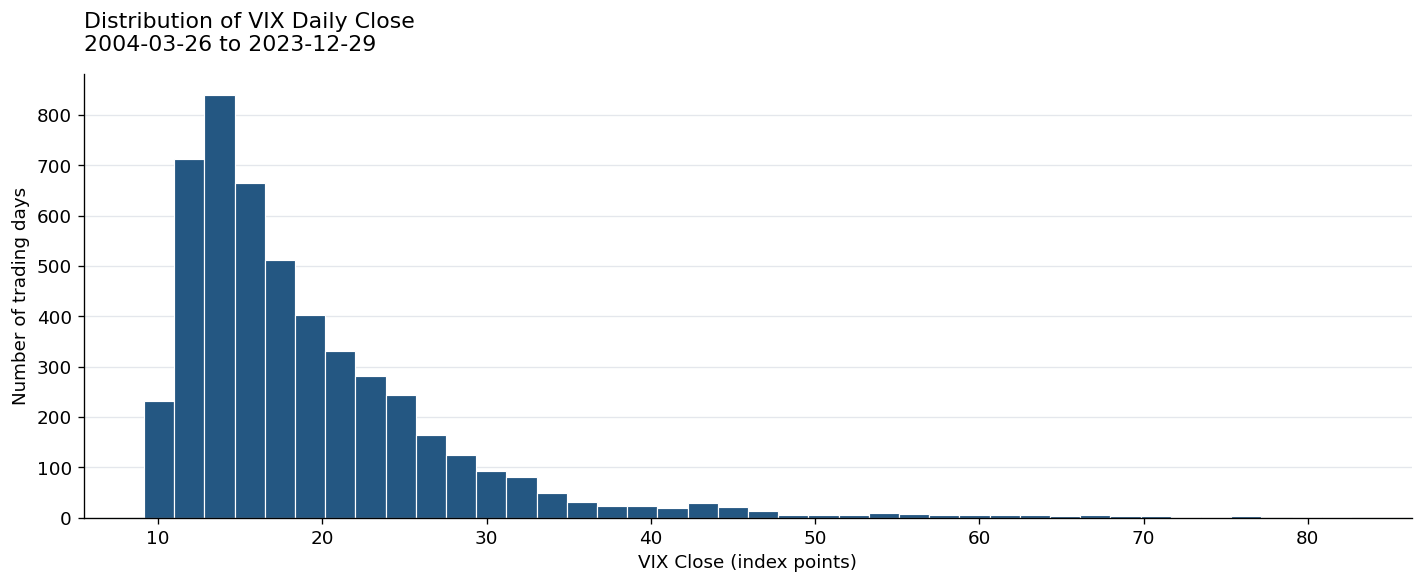

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(vix["Close"], bins=40, color="#245782", edgecolor="white", linewidth=0.7)
ax.set_title(f"Distribution of VIX Daily Close\n{period_label}", loc="left", pad=14)
ax.set_xlabel("VIX Close (index points)")
ax.set_ylabel("Number of trading days")
ax.grid(axis="y", color="#d9dee4", alpha=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


<a id="section-3"></a>

## 3. VIX Daily Range (High − Low)

Daily range is a measure of the dispersion of the VIX, whichis somehow linked to the volatility of volatility (VVIX). As we can see, the daily range has also a long tail, and substantially increases as the VIX increases. This means that VVIX can add value as a trading signal.

VIX daily range: High - Low
Study period: 2004-03-26 to 2023-12-29
Daily observations: 4,975


,Daily range (index points)
Statistic,
Minimum,0.18
Maximum,27.88
P25,0.85
P50,1.34
P75,2.20


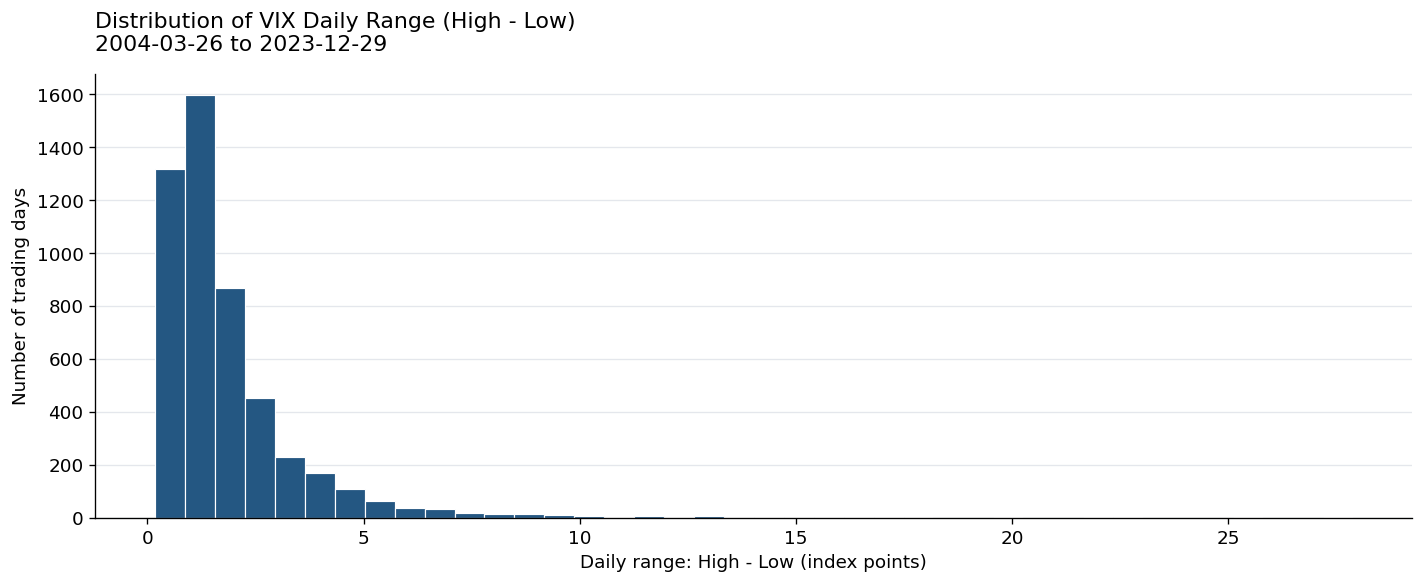

In [5]:
# Daily VIX range: High - Low, in index points. Run sections 1 and 2 first.
vix_high_low = pd.read_csv(DATA_FILE, usecols=["Date", "High", "Low"], dtype="string")
vix_high_low["Date"] = pd.to_datetime(
    vix_high_low["Date"], format="%Y-%m-%d", errors="raise"
)
if vix_high_low["Date"].isna().any():
    raise ValueError("The input file contains missing dates.")

# Apply the validation cutoff before converting prices or calculating ranges.
vix_high_low = vix_high_low.loc[vix_high_low["Date"] <= END_DATE].copy()
if vix_high_low.empty:
    raise ValueError("No High/Low observations are available on or before the cutoff.")
if vix_high_low["Date"].duplicated().any():
    raise ValueError("Duplicate dates were found in the study period.")

for price_column in ["High", "Low"]:
    vix_high_low[price_column] = pd.to_numeric(
        vix_high_low[price_column], errors="raise"
    ).astype(float)
    if (
        not np.isfinite(vix_high_low[price_column]).all()
        or (vix_high_low[price_column] <= 0).any()
    ):
        raise ValueError(f"The study period contains missing or invalid VIX {price_column} values.")

if (vix_high_low["High"] < vix_high_low["Low"]).any():
    raise ValueError("The study period contains High values below Low values.")

vix_high_low = vix_high_low.sort_values("Date").set_index("Date")
if not vix_high_low.index.equals(vix.index):
    raise ValueError("High/Low dates differ from the Close sample. Rerun section 2.")

vix_daily_range = (vix_high_low["High"] - vix_high_low["Low"]).rename("Daily range")
range_percentiles = vix_daily_range.quantile([0.25, 0.50, 0.75], interpolation="linear")
daily_range_summary = pd.Series({
    "Minimum": vix_daily_range.min(),
    "Maximum": vix_daily_range.max(),
    "P25": range_percentiles.loc[0.25],
    "P50": range_percentiles.loc[0.50],
    "P75": range_percentiles.loc[0.75],
}, name="Daily range (index points)").rename_axis("Statistic").to_frame()

print("VIX daily range: High - Low")
print(f"Study period: {period_label}")
print(f"Daily observations: {len(vix_daily_range):,}")
# Display two decimals; calculations and the histogram retain full precision.
with pd.option_context("display.float_format", "{:.2f}".format):
    display(daily_range_summary)

range_fig, range_ax = plt.subplots(figsize=(12, 5))
range_ax.hist(
    vix_daily_range, bins=40, color="#245782", edgecolor="white", linewidth=0.7
)
range_ax.set_title(
    f"Distribution of VIX Daily Range (High - Low)\n{period_label}", loc="left", pad=14
)
range_ax.set_xlabel("Daily range: High - Low (index points)")
range_ax.set_ylabel("Number of trading days")
range_ax.grid(axis="y", color="#d9dee4", alpha=0.7)
range_ax.set_axisbelow(True)
range_fig.tight_layout()
plt.show()


<a id="section-4"></a>

## 4. Close percentiles

After a brief exploration of the data, we have selected 4 percentile levels to define five interpretable VIX states for the transition analysis. They are the 55th, 76th, 90th, and 96th percentiles.

This unequal partition groups lower VIX observations into a broad state while distinguishing progressively elevated volatility conditions. The resulting states contain approximately 55%, 21%, 14%, 6%, and 4% of the observations of the sample, respectively.

The thresholds are choices heuristically designed, with the intention to balance simplicity with greater differentiation of elevated-volatility conditions. They are not claimed to be statistically optimal boundaries or formally identified market regimes.


In [6]:
percentile_values = vix["Close"].quantile(
    [p / 100 for p in PERCENTILES], interpolation="linear"
)
percentile_values.index = pd.Index(PERCENTILES, name="Percentile")
percentile_table = percentile_values.rename("VIX Close").to_frame()

with pd.option_context("display.float_format", "{:.2f}".format):
    display(percentile_table)


,VIX Close
Percentile,
55,17.50
76,22.54
90,28.81
96,37.81


<a id="section-5"></a>

## 5. VIX History and Daily Range by Percentile State

Below, we present a chart showing the evolution of the VIX and the different percentile levels. We also study the High–Low range of the daily VIX candles within each percentile range.

The H–L range provides a simple measure of VIX variability, which may help us assess the potential relevance of the VVIX index, which we will study later. We can observe that the H–L range of the daily candles increases substantially as the VIX rises.

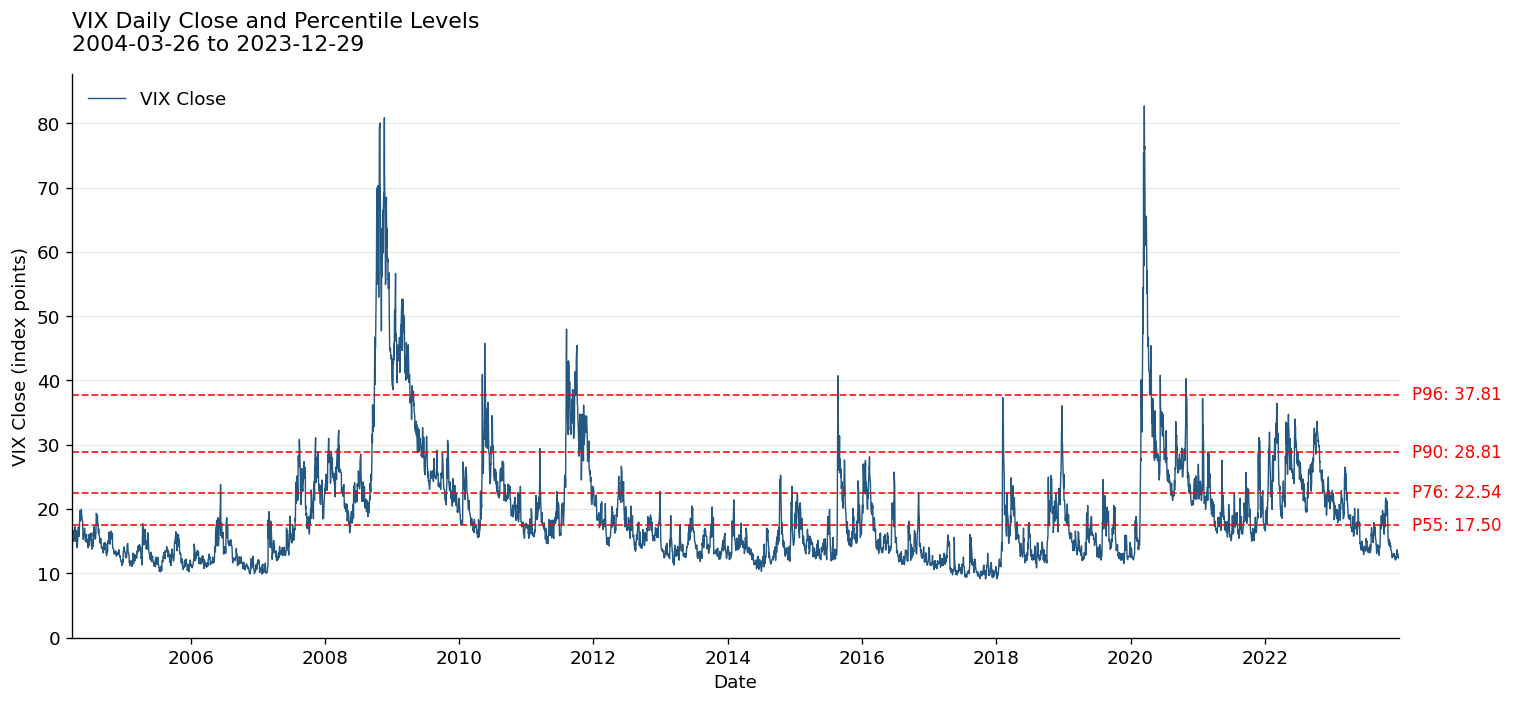

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(vix.index, vix["Close"], color="#245782", linewidth=0.85, label="VIX Close")

for percentile, level in percentile_values.items():
    ax.axhline(level, color="red", linestyle="--", linewidth=1.1, alpha=0.85)
    ax.text(
        1.01, level, f"P{percentile}: {level:.2f}",
        transform=ax.get_yaxis_transform(), color="red",
        va="center", ha="left", fontsize=10, clip_on=False,
    )

ax.set_title(f"VIX Daily Close and Percentile Levels\n{period_label}", loc="left", pad=14)
ax.set_xlabel("Date")
ax.set_ylabel("VIX Close (index points)")
ax.set_xlim(vix.index.min(), vix.index.max())
ax.set_ylim(0, vix["Close"].max() * 1.06)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="y", color="#d9dee4", alpha=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False)
fig.tight_layout(rect=(0, 0, 0.91, 1))
plt.show()


In [8]:
# Average daily High - Low within each Close percentile range.
# Reuse the filtered Close sample, unrounded percentiles, and section 3 ranges.
if (
    vix.empty or vix.index.max() > END_DATE
    or not vix_daily_range.index.equals(vix.index)
):
    raise ValueError("Run sections 2-4 first to align the data and apply the cutoff.")

close_range_thresholds = percentile_values.loc[[55, 76, 90, 96]]
close_range_edges = np.r_[-np.inf, close_range_thresholds.to_numpy(), np.inf]
close_range_labels = ["At or below P55", "P55–P76", "P76–P90", "P90–P96", "Above P96"]

daily_range_by_close = pd.DataFrame({
    "Close": vix["Close"],
    "Daily range": vix_daily_range,
})
daily_range_by_close["Close percentile range"] = pd.cut(
    daily_range_by_close["Close"], bins=close_range_edges,
    labels=close_range_labels, right=True, include_lowest=True,
)

# Each trading day has equal weight and belongs to exactly one interval.
mean_range_by_percentile = (
    daily_range_by_close.groupby("Close percentile range", observed=False)["Daily range"]
    .agg(["size", "mean"])
    .rename(columns={
        "size": "Trading days",
        "mean": "Mean High - Low (index points)",
    })
)
mean_range_by_percentile.insert(0, "Close interval (index points)", [
    f"Close ≤ {close_range_thresholds.loc[55]:.2f}",
    f"{close_range_thresholds.loc[55]:.2f} < Close ≤ {close_range_thresholds.loc[76]:.2f}",
    f"{close_range_thresholds.loc[76]:.2f} < Close ≤ {close_range_thresholds.loc[90]:.2f}",
    f"{close_range_thresholds.loc[90]:.2f} < Close ≤ {close_range_thresholds.loc[96]:.2f}",
    f"Close > {close_range_thresholds.loc[96]:.2f}",
])

# Preserve full precision in the data; format only the displayed table.
from html import escape
from IPython.display import HTML

print(f"Study period: {period_label}")
print("Days are classified by Close. Interval limits are displayed rounded; classification uses full precision.")

range_table_rows = []
for range_row_number, (range_state, range_row) in enumerate(mean_range_by_percentile.iterrows()):
    range_background = "#f1f5f9" if range_row_number % 2 == 0 else "#ffffff"
    range_table_rows.append(
        f'<tr style="background:{range_background};">'
        f'<th scope="row" style="padding:10px 18px;text-align:left;font-weight:400;'
        f'white-space:nowrap;border-bottom:1px solid #e2e8f0;">{escape(str(range_state))}</th>'
        f'<td style="padding:10px 18px;text-align:left;white-space:nowrap;'
        f'font-variant-numeric:tabular-nums;border-bottom:1px solid #e2e8f0;">'
        f'{escape(range_row["Close interval (index points)"])}</td>'
        f'<td style="padding:10px 18px;text-align:right;font-weight:600;'
        f'font-variant-numeric:tabular-nums;border-bottom:1px solid #e2e8f0;">'
        f'{int(range_row["Trading days"]):,}</td>'
        f'<td style="padding:10px 18px;text-align:right;font-weight:600;'
        f'font-variant-numeric:tabular-nums;border-bottom:1px solid #e2e8f0;">'
        f'{range_row["Mean High - Low (index points)"]:,.2f}</td></tr>'
    )

range_table_html = (
    '<div style="max-width:1000px;margin:14px 0 8px;overflow-x:auto;'
    'font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;color:#182b3a;">'
    '<table aria-label="Mean Daily Range by VIX State" '
    'style="width:100%;border-collapse:collapse;font-size:14px;line-height:1.4;'
    'border:1px solid #dce5ed;">'
    '<caption style="caption-side:top;text-align:left;padding:0 0 12px;'
    'font-size:18px;font-weight:650;color:#245782;">Mean Daily Range by VIX State</caption>'
    '<thead><tr style="background:#245782;color:#ffffff;">'
    '<th scope="col" style="padding:12px 18px;text-align:left;font-weight:600;">VIX state</th>'
    '<th scope="col" style="padding:12px 18px;text-align:left;font-weight:600;">'
    'Close interval<br>(index points)</th>'
    '<th scope="col" style="padding:12px 18px;text-align:right;font-weight:600;">Trading days</th>'
    '<th scope="col" style="padding:12px 18px;text-align:right;font-weight:600;">'
    'Mean High − Low<br>(index points)</th>'
    '</tr></thead><tbody>' + "".join(range_table_rows) + '</tbody></table></div>'
)
display(HTML(range_table_html))


Study period: 2004-03-26 to 2023-12-29
Days are classified by Close. Interval limits are displayed rounded; classification uses full precision.


VIX state,Close interval(index points),Trading days,Mean High − Low(index points)
At or below P55,Close ≤ 17.50,"2,738",1.12
P55–P76,17.50 < Close ≤ 22.54,"1,044",1.96
P76–P90,22.54 < Close ≤ 28.81,695,2.54
P90–P96,28.81 < Close ≤ 37.81,300,4.11
Above P96,Close > 37.81,198,6.61


<a id="section-6"></a>

## 6. States and Entry Events

We now study two possible entry conditions: entering a VIX state while moving
upward, or entering the same state while moving downward. We want to understand
how often the VIX relaxes, how long this takes, and how long it then remains in
Low VIX. These are descriptive studies of VIX behavior, not returns from an
investment product. We use the original Close and the percentile thresholds
from section 4, through **December 29, 2023**.

- **State 1:** Close ≤ P55; **state 2:** P55 < Close ≤ P76;
  **state 3:** P76 < Close ≤ P90; **state 4:** P90 < Close ≤ P96;
  **state 5:** Close > P96. Calculations use unrounded thresholds.
- **Upward entry:** the state changes from *i − 1* to *i*, for states 2–5.
  **Downward entry:** the state changes from *i + 1* to *i*, for states 2–4.
  All observed entries into state 1 are studied separately as Low VIX episodes.
- Only the crossing date starts an entry event. A movement within the same state
  does not create another event. The crossing date is **session 0**; the next
  observed trading session is session 1. Day count is based on trading days.
- Entries that skip states (double jumps or more) are identified separately and excluded 
  from the main upward/downward comparisons. We do not infer observations in skipped states.
  A later exit can skip states: any state below the entered state is a lower exit.
- Entry groups are selected using only the current and previous state.
  **Subsequent increases and unsuccessful outcomes remain in the analysis.**
  Repeated entries and overlapping follow-up windows are not independent samples.

The full-sample count also includes consecutive closes that remain in the
same state. These comparisons do not create new entry events. With **N daily
closes, there are N − 1 consecutive-close comparisons**, because the first
Close has no preceding observation. The mutually exclusive categories in the
count table add up to that total.

We use **5 and 15 trading sessions**, approximately one and three trading weeks.
The endpoint matrices show the state exactly at each horizon. A separate path
table shows which boundary was crossed first, and whether state 1 was reached
at any time within the horizon. Reaching state 1 may include an earlier adverse
increase (re-jump); the path and endpoint measures answer different questions.

An entry without a complete horizon before the cutoff is reported separately.
An entry with complete follow-up that does not reach its objective remains in
the denominator. A row without eligible entries is **N/A**, not zero probability.
Full episode-duration statistics use observed completed exits; unresolved
durations remain open and are not replaced by their age at the cutoff.

We call these **empirical transition matrices**, rather than a Markov model.
Each horizon is counted directly from entry events, without matrix powers or
an assumption that the current state captures all relevant history.


In [9]:
from html import escape
from IPython.display import HTML

HORIZONS = (5, 15)
STATE_IDS = [1, 2, 3, 4, 5]
STATE_NAMES = {
    1: "1 · ≤P55", 2: "2 · P55–P76", 3: "3 · P76–P90",
    4: "4 · P90–P96", 5: "5 · >P96",
}
ENTRY_STATES = {"Upward": [2, 3, 4, 5], "Downward": [2, 3, 4]}


def show_study_table(frame, caption, formats=None):
    """Display compact tables without changing stored values or requiring Styler."""
    formats = formats or {}
    headers = [frame.index.name or "State"] + list(frame.columns)
    header_html = "".join(
        '<th scope="col" style="padding:11px 14px;text-align:left;font-weight:600;">'
        + escape(str(label)) + '</th>' for label in headers
    )
    rows = []
    for row_number, (label, row) in enumerate(frame.iterrows()):
        background = "#f1f5f9" if row_number % 2 == 0 else "#ffffff"
        cells = [f'<th scope="row" style="padding:10px 14px;text-align:left;'
                 f'font-weight:400;white-space:nowrap;">{escape(str(label))}</th>']
        for column, value in row.items():
            if pd.isna(value):
                text = "N/A"
            elif column in formats:
                text = formats[column].format(value)
            elif pd.api.types.is_integer_dtype(frame[column].dtype):
                text = f"{int(value):,}"
            elif isinstance(value, (int, np.integer)):
                text = f"{value:,}"
            elif isinstance(value, (float, np.floating)):
                text = f"{value:,.2f}"
            else:
                text = str(value)
            cells.append('<td style="padding:10px 14px;text-align:right;'
                         'font-variant-numeric:tabular-nums;">' + escape(text) + '</td>')
        rows.append(f'<tr style="background:{background};border-bottom:1px solid #e2e8f0;">'
                    + "".join(cells) + '</tr>')
    display(HTML(
        '<div style="max-width:1250px;margin:16px 0;overflow-x:auto;'
        'font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;color:#182b3a;">'
        '<table style="width:100%;border-collapse:collapse;font-size:14px;line-height:1.4;'
        'border:1px solid #dce5ed;">'
        '<caption style="caption-side:top;text-align:left;padding:0 0 12px;'
        'font-size:18px;font-weight:650;color:#245782;">' + escape(caption) + '</caption>'
        '<thead><tr style="background:#245782;color:white;">' + header_html + '</tr></thead>'
        '<tbody>' + "".join(rows) + '</tbody></table></div>'
    ))


def collect_entry_events(close, states):
    """Record observed state entries, then describe their subsequent paths."""
    if not close.index.equals(states.index) or close.empty:
        raise ValueError("Close and state series must be nonempty and aligned.")
    if not close.index.is_unique or not close.index.is_monotonic_increasing:
        raise ValueError("Dates must be unique and sorted.")
    if states.isna().any() or not states.isin(STATE_IDS).all():
        raise ValueError("Every Close must have a valid state.")
    values = states.to_numpy(dtype=int)
    rows = []
    for position in np.flatnonzero(values[1:] != values[:-1]) + 1:
        previous, entered = int(values[position - 1]), int(values[position])
        future = values[position + 1:]
        exits = np.flatnonzero(future != entered)
        lowers = np.flatnonzero(future < entered)
        lows = np.flatnonzero(future == 1)
        exit_sessions = int(exits[0] + 1) if exits.size else np.nan
        exit_state = int(future[exits[0]]) if exits.size else np.nan
        exit_kind = ("Lower" if exit_state < entered else "Higher") if exits.size else "Open"
        rows.append({
            "Event": len(rows) + 1, "Start position": int(position),
            "Start": close.index[position], "Previous state": previous,
            "Entry state": entered, "Entry Close": float(close.iloc[position]),
            "Direction": "Upward" if entered > previous else "Downward",
            "Entry type": "Adjacent" if abs(entered - previous) == 1 else "Multiple-state jump",
            "First exit": exit_kind, "Exit sessions": exit_sessions,
            "Exit state": exit_state,
            "Exit date": close.index[position + int(exit_sessions)] if exits.size else pd.NaT,
            "First lower sessions": int(lowers[0] + 1) if lowers.size else np.nan,
            "First Low VIX sessions": int(lows[0] + 1) if lows.size else np.nan,
            "Observed age": len(close) - 1 - int(position),
        })
    columns = [
        "Event", "Start position", "Start", "Previous state", "Entry state", "Entry Close",
        "Direction", "Entry type", "First exit", "Exit sessions", "Exit state", "Exit date",
        "First lower sessions", "First Low VIX sessions", "Observed age",
    ]
    return pd.DataFrame(rows, columns=columns)


def analyze_entry_horizon(events, close, states, horizon, origin_states):
    """Use all eligible entry events; never select by their later outcome."""
    if not isinstance(horizon, (int, np.integer)) or horizon < 1:
        raise ValueError("The horizon must be a positive number of trading sessions.")
    eligible = events.loc[events["Observed age"] >= horizon].copy()
    incomplete = events.loc[events["Observed age"] < horizon].copy()
    positions = eligible["Start position"].to_numpy(dtype=int)
    eligible["Horizon date"] = close.index[positions + horizon]
    eligible["End state"] = states.iloc[positions + horizon].to_numpy(dtype=int)
    eligible["First exit by horizon"] = np.where(
        eligible["Exit sessions"].le(horizon), eligible["First exit"], "No exit yet"
    )
    eligible["Reached Low VIX"] = eligible["First Low VIX sessions"].le(horizon)
    eligible["Reached a lower state"] = eligible["First lower sessions"].le(horizon)
    eligible["Maximum VIX increase"] = [
        float(close.iloc[p:p + horizon + 1].max() - close.iloc[p]) for p in positions
    ]
    counts = pd.DataFrame(0, index=STATE_IDS, columns=STATE_IDS, dtype=int)
    for origin, destination in zip(eligible["Entry state"], eligible["End state"]):
        counts.loc[int(origin), int(destination)] += 1
    counts.index.name = "Entry state"
    counts.columns.name = f"State after {horizon} sessions"
    totals = counts.sum(axis=1)
    probabilities = counts.div(totals.replace(0, np.nan), axis=0)
    rows = []
    for state in origin_states:
        observed = eligible.loc[eligible["Entry state"] == state]
        n = len(observed)
        rows.append({
            "State": STATE_NAMES[state], "Eligible entries": n,
            "Incomplete follow-up": int((incomplete["Entry state"] == state).sum()),
            "Lower exit first": (observed["First exit by horizon"] == "Lower").mean() if n else np.nan,
            "Higher exit first": (observed["First exit by horizon"] == "Higher").mean() if n else np.nan,
            "No exit yet": (observed["First exit by horizon"] == "No exit yet").mean() if n else np.nan,
            "Reached state 1": observed["Reached Low VIX"].mean() if n else np.nan,
        })
    return {
        "counts": counts, "probabilities": probabilities, "eligible": eligible,
        "incomplete": incomplete, "summary": pd.DataFrame(rows).set_index("State"),
    }


def summarize_contained_durations(events, origin_states):
    """Full observed durations, conditional on the first exit being lower."""
    rows = []
    for state in origin_states:
        selected = events.loc[events["Entry state"] == state]
        durations = selected.loc[selected["First exit"] == "Lower", "Exit sessions"]
        rows.append({
            "State": STATE_NAMES[state], "Entries": len(selected),
            "Lower first": int((selected["First exit"] == "Lower").sum()),
            "Higher first": int((selected["First exit"] == "Higher").sum()),
            "Open at cutoff": int((selected["First exit"] == "Open").sum()),
            "Mean sessions": durations.mean(), "Median sessions": durations.median(),
        })
    return pd.DataFrame(rows).set_index("State")


if vix.empty or vix.index.max() > END_DATE:
    raise ValueError("Run sections 1–4 first, using the study cutoff.")
study_thresholds = percentile_values.loc[[55, 76, 90, 96]]
study_states = pd.cut(
    vix["Close"], bins=np.r_[-np.inf, study_thresholds.to_numpy(), np.inf],
    labels=STATE_IDS, right=True, include_lowest=True,
).astype(int).rename("State")
entry_events = collect_entry_events(vix["Close"], study_states)
jump_events = entry_events.loc[entry_events["Entry type"] == "Multiple-state jump"].copy()
primary_entries = {
    direction: entry_events.loc[
        (entry_events["Direction"] == direction)
        & (entry_events["Entry type"] == "Adjacent")
        & entry_events["Entry state"].isin(origin_states)
    ].copy()
    for direction, origin_states in ENTRY_STATES.items()
}
directional_results = {
    direction: {
        h: analyze_entry_horizon(events, vix["Close"], study_states, h, ENTRY_STATES[direction])
        for h in HORIZONS
    }
    for direction, events in primary_entries.items()
}
contained_duration_summary = {
    direction: summarize_contained_durations(events, ENTRY_STATES[direction])
    for direction, events in primary_entries.items()
}

state_definition_table = pd.DataFrame({
    "State": [STATE_NAMES[i] for i in STATE_IDS],
    "Close interval (index points)": [
        f"Close ≤ {study_thresholds.loc[55]:.2f}",
        f"{study_thresholds.loc[55]:.2f} < Close ≤ {study_thresholds.loc[76]:.2f}",
        f"{study_thresholds.loc[76]:.2f} < Close ≤ {study_thresholds.loc[90]:.2f}",
        f"{study_thresholds.loc[90]:.2f} < Close ≤ {study_thresholds.loc[96]:.2f}",
        f"Close > {study_thresholds.loc[96]:.2f}",
    ],
    "Trading sessions": study_states.value_counts().reindex(STATE_IDS, fill_value=0).to_numpy(),
}).set_index("State")
show_study_table(state_definition_table, "VIX States — Full-Precision Thresholds Used in Calculations")

entry_inventory = pd.DataFrame([
    {"Direction": direction, "Primary adjacent entries": len(primary_entries[direction]),
     "Adjacent entries into state 1": int(((entry_events["Direction"] == direction)
        & (entry_events["Entry type"] == "Adjacent") & (entry_events["Entry state"] == 1)).sum()),
     "Multiple-state jumps": int((jump_events["Direction"] == direction).sum())}
    for direction in ENTRY_STATES
]).set_index("Direction")
show_study_table(entry_inventory, "Entry Events — Adjacent Crossings and Separate Jumps")

# Account for every consecutive pair, including pairs that create no new entry.
# The first observation has no predecessor; never fill its missing difference with zero.
daily_state_changes = study_states.diff().iloc[1:]
daily_destination_states = study_states.iloc[1:]
daily_comparison_counts = pd.DataFrame({
    "Comparison type": [
        "Same state — no new entry",
        "Adjacent upward entries",
        "Adjacent downward entries into states 2–4",
        "Adjacent downward entries into state 1",
        "Multiple-state jumps — either direction",
    ],
    "Count": [
        int(daily_state_changes.eq(0).sum()),
        int(daily_state_changes.eq(1).sum()),
        int((daily_state_changes.eq(-1) & daily_destination_states.ne(1)).sum()),
        int((daily_state_changes.eq(-1) & daily_destination_states.eq(1)).sum()),
        int(daily_state_changes.abs().gt(1).sum()),
    ],
}).set_index("Comparison type")
total_daily_comparisons = len(study_states) - 1
assert daily_comparison_counts["Count"].sum() == total_daily_comparisons
assert daily_comparison_counts.iloc[1:, 0].sum() == len(entry_events)
assert daily_comparison_counts.loc["Adjacent upward entries", "Count"] == len(primary_entries["Upward"])
assert daily_comparison_counts.loc["Adjacent downward entries into states 2–4", "Count"] == len(primary_entries["Downward"])
assert daily_comparison_counts.loc["Adjacent downward entries into state 1", "Count"] == entry_inventory.loc["Downward", "Adjacent entries into state 1"]
assert daily_comparison_counts.loc["Multiple-state jumps — either direction", "Count"] == len(jump_events)
daily_comparison_counts.loc["Total consecutive-close comparisons", "Count"] = total_daily_comparisons
daily_comparison_counts["Count"] = daily_comparison_counts["Count"].astype(int)
show_study_table(daily_comparison_counts, "Daily State Comparisons — Full Sample Count")
display(HTML(
    '<p style="font-size:13px;color:#536574;margin:0 0 18px;">'
    f'{len(study_states):,} daily closes produce {total_daily_comparisons:,} consecutive-close comparisons. '
    'The first Close has no preceding observation. Same-state comparisons do not create new entry events.'
    '</p>'
))

if not jump_events.empty:
    jump_inventory = jump_events.groupby(["Previous state", "Entry state"]).size().rename("Events").to_frame()
    jump_inventory.index = [f"{a} → {b}" for a, b in jump_inventory.index]
    jump_inventory.index.name = "Observed jump"
    show_study_table(jump_inventory, "Multiple-State Jumps — Excluded from the Primary Entry Comparisons")

# Futures are used only to describe curve conditions, never to define an entry.
FUTURES_FILE = DATA_DIR / "VIX_Futures_Term_Structure_F1_F2.csv"
futures = pd.read_csv(FUTURES_FILE, usecols=["Date", "F1", "F2"], dtype="string")
futures["Date"] = pd.to_datetime(futures["Date"], format="%Y-%m-%d", errors="raise")
if futures["Date"].isna().any():
    raise ValueError("Missing futures dates.")
futures = futures.loc[futures["Date"] <= END_DATE].copy()
if futures.empty or futures["Date"].duplicated().any():
    raise ValueError("The futures sample is empty or contains duplicate dates.")
for column in ["F1", "F2"]:
    futures[column] = pd.to_numeric(futures[column], errors="raise").astype(float)
    known_prices = futures[column].dropna()
    if not np.isfinite(known_prices).all() or (known_prices <= 0).any():
        raise ValueError(f"Invalid {column} prices in the study period.")
futures = futures.sort_values("Date").set_index("Date")
curve_data = vix[["Close"]].join(futures[["F1", "F2"]], how="left")
curve_data["State"] = study_states
curve_available = curve_data[["F1", "F2"]].notna().all(axis=1)
if not curve_available.all():
    raise ValueError("F1 and F2 must cover every VIX date in the study period. Use the complete futures CSV starting in 2004.")
curve_data["Curve"] = "Flat"
curve_data.loc[curve_available & (curve_data["F2"] > curve_data["F1"]), "Curve"] = "Contango"
curve_data.loc[curve_available & (curve_data["F1"] > curve_data["F2"]), "Curve"] = "Backwardation"
curve_data.loc[curve_available & (curve_data["F1"] == curve_data["F2"]), "Curve"] = "Flat"
curve_rows = []
for state in STATE_IDS:
    sample = curve_data.loc[curve_data["State"] == state]
    known = sample["Curve"]
    curve_rows.append({
        "State": STATE_NAMES[state], "Matched days": len(known),
        "Contango": (known == "Contango").mean() if len(known) else np.nan,
        "Backwardation": (known == "Backwardation").mean() if len(known) else np.nan,
        "Flat": (known == "Flat").mean() if len(known) else np.nan,
    })
curve_by_state = pd.DataFrame(curve_rows).set_index("State")
print(f"Study period: {period_label}. Entry dates are session 0; all horizons count trading sessions.")


Study period: 2004-03-26 to 2023-12-29. Entry dates are session 0; all horizons count trading sessions.


State,Close interval (index points),Trading sessions
1 · ≤P55,Close ≤ 17.50,"2,738"
2 · P55–P76,17.50 < Close ≤ 22.54,"1,044"
3 · P76–P90,22.54 < Close ≤ 28.81,695
4 · P90–P96,28.81 < Close ≤ 37.81,300
5 · >P96,Close > 37.81,198


Direction,Primary adjacent entries,Adjacent entries into state 1,Multiple-state jumps
Upward,298,0,9
Downward,179,138,0


Comparison type,Count
Same state — no new entry,"4,350"
Adjacent upward entries,298
Adjacent downward entries into states 2–4,179
Adjacent downward entries into state 1,138
Multiple-state jumps — either direction,9
Total consecutive-close comparisons,"4,974"


Observed jump,Events
1 → 3,4
1 → 4,1
2 → 4,1
3 → 5,3


In [10]:
def plot_transition_heatmap(counts, probabilities, direction, horizon, period_label):
    """Plot entry-conditioned endpoint probabilities for all five states."""
    from matplotlib.ticker import PercentFormatter

    states = list(range(1, 6))
    intervals = ["≤P55", "P55–P76", "P76–P90", "P90–P96", ">P96"]
    labels = [f"State {state}\n{interval}" for state, interval in zip(states, intervals)]
    values = probabilities.reindex(index=states, columns=states).to_numpy(
        dtype=float, na_value=np.nan
    )
    ordered_counts = counts.reindex(index=states, columns=states, fill_value=0)
    total = int(ordered_counts.to_numpy().sum())
    cmap = plt.get_cmap("Blues").copy()
    cmap.set_bad("#eeeeee")
    fig, ax = plt.subplots(figsize=(10.8, 8.7))
    image = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(5), labels)
    ax.set_yticks(np.arange(5), labels)
    ax.set_xlabel(f"Destination state exactly {horizon} trading sessions after entry", labelpad=12)
    ax.set_ylabel("Entered state at session 0", labelpad=12)
    ax.set_title(
        f"VIX Close: {direction} Entries — {horizon}-Session Endpoint Probabilities\n"
        f"{period_label}", loc="left", pad=17,
    )
    for row in range(5):
        for column in range(5):
            probability = values[row, column]
            count = int(ordered_counts.iloc[row, column])
            annotation = (
                f"{probability:.2%}\n(n={count:,})"
                if np.isfinite(probability) else "N/A\n(no eligible entries)"
            )
            ax.text(
                column, row, annotation, ha="center", va="center",
                fontsize=10 if np.isfinite(probability) else 8.5,
                color="white" if np.isfinite(probability) and probability > 0.55 else "#193349",
            )
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    colorbar.set_label("Probability conditional on the entered state")
    fig.text(
        0.08, 0.035,
        f"{total:,} eligible adjacent {direction.lower()} entries with complete {horizon}-session follow-up. "
        "Each eligible row sums to 100%.\n"
        "Diagonal = same final state; exits and returns before the endpoint are allowed. N/A = no eligible entries.",
        ha="left", va="bottom", fontsize=9, color="#555555", linespacing=1.5,
    )
    fig.tight_layout(rect=(0, 0.085, 1, 1))
    plt.show()
    return fig


def plot_transition_diagram(counts, probabilities, direction, horizon, period_label):
    """Preserve the ordered-state diagram and draw every positive endpoint count."""
    from matplotlib.patches import Ellipse, FancyArrowPatch
    from matplotlib.path import Path as MplPath
    from matplotlib.lines import Line2D

    states = list(range(1, 6))
    intervals = ["≤P55", "P55–P76", "P76–P90", "P90–P96", ">P96"]
    counts = counts.reindex(index=states, columns=states, fill_value=0)
    probabilities = probabilities.reindex(index=states, columns=states)
    totals = counts.sum(axis=1)
    positions = np.arange(5, dtype=float) * 3.65
    upper_color, lower_color, stay_color = "#b65c28", "#245782", "#71808d"
    fills = ["#e6f0f7", "#dcebf4", "#f5eddb", "#f9dfc8", "#f3c9c9"]
    fig, ax = plt.subplots(figsize=(16, 10.5))

    def draw_arrow(vertices, codes, color, dashed=False):
        ax.add_patch(FancyArrowPatch(
            path=MplPath(vertices, codes), arrowstyle="-|>", mutation_scale=14,
            linewidth=1.6, color=color, linestyle="--" if dashed else "-", zorder=1,
        ))

    def label_arrow(x, y, origin, destination, color):
        probability = float(probabilities.loc[origin, destination])
        count = int(counts.loc[origin, destination])
        ax.text(
            x, y, f"{probability:.2%} (n={count:,})", ha="center", va="center",
            color=color, fontsize=9.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.97, pad=2.5), zorder=4,
        )

    # Adjacent endpoints keep the original short arcs above or below the nodes.
    for origin in states[:-1]:
        destination = origin + 1
        left, right = positions[origin - 1], positions[destination - 1]
        midpoint = (left + right) / 2
        for first, last, sign, color in [
            (origin, destination, 1, upper_color),
            (destination, origin, -1, lower_color),
        ]:
            if counts.loc[first, last] <= 0:
                continue
            start, end = (left + 1.17, right - 1.17) if sign > 0 else (right - 1.17, left + 1.17)
            draw_arrow(
                [(start, sign * 0.37), (midpoint, sign * 2.18), (end, sign * 0.37)],
                [MplPath.MOVETO, MplPath.CURVE3, MplPath.CURVE3], color,
            )
            label_arrow(midpoint, sign * 1.46, first, last, color)

    # Separate lanes make all nonadjacent edges and their labels visible.
    # These are endpoint changes, not claims about the route between endpoints.
    extents = {1: 2.35, -1: 2.85}
    for sign, color in [(1, upper_color), (-1, lower_color)]:
        edges = [
            (origin, destination)
            for origin in states for destination in states
            if (destination - origin) * sign > 1 and counts.loc[origin, destination] > 0
        ]
        edges.sort(key=lambda edge: (abs(edge[1] - edge[0]), edge[0]))
        for lane, (origin, destination) in enumerate(edges):
            height = sign * (4.15 + lane * 1.02)
            x0, x1 = positions[origin - 1], positions[destination - 1]
            # Small offsets separate the otherwise coincident arrow tips.
            distance = abs(destination - origin)
            port_offset = 0.18 * (distance - 2)
            start_x, end_x = x0 + sign * port_offset, x1 - sign * port_offset
            port_y = sign * 0.85 * np.sqrt(1 - (port_offset / 1.36) ** 2)
            draw_arrow(
                [(start_x, port_y), (start_x, height), (end_x, height), (end_x, port_y)],
                [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4],
                color, dashed=True,
            )
            label_y = 0.25 * port_y + 0.75 * height + sign * 0.22
            label_arrow((start_x + end_x) / 2, label_y, origin, destination, color)
            extents[sign] = max(extents[sign], abs(label_y) + 0.55)

    for state, interval, x, fill in zip(states, intervals, positions, fills):
        total = int(totals.loc[state])
        diagonal_count = int(counts.loc[state, state])
        if diagonal_count > 0:
            draw_arrow(
                [(x - 0.47, -0.80), (x - 1.28, -2.70), (x + 1.28, -2.70), (x + 0.47, -0.80)],
                [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4], stay_color,
            )
            label_arrow(x, -2.40, state, state, stay_color)
        ax.add_patch(Ellipse(
            (x, 0), 2.72, 1.70, facecolor=fill if total else "#eeeeee",
            edgecolor="#536574", linewidth=1.4, zorder=3,
        ))
        ax.text(x, 0.47, f"State {state}", ha="center", va="center", fontsize=12, fontweight="bold", zorder=4)
        ax.text(x, 0.13, interval, ha="center", va="center", fontsize=11, zorder=4)
        if total:
            ax.text(
                x, -0.23, f"Same state: {float(probabilities.loc[state, state]):.2%}",
                ha="center", va="center", fontsize=9.5, color="#354a5b", zorder=4,
            )
            ax.text(x, -0.52, f"Eligible entries: {total:,}", ha="center", va="center", fontsize=9, color="#536574", zorder=4)
        else:
            ax.text(x, -0.31, "No eligible entries", ha="center", va="center", fontsize=9.5, color="#536574", zorder=4)

    ax.set_xlim(-1.65, positions[-1] + 1.65)
    ax.set_ylim(-extents[-1], extents[1])
    ax.axis("off")
    ax.set_title(
        f"VIX Close: {direction} Entries — {horizon}-Session Endpoint Transitions\n{period_label}",
        loc="left", pad=19,
    )
    fig.legend(handles=[
        Line2D([0], [0], color=upper_color, lw=1.6, label="Ends in a higher state"),
        Line2D([0], [0], color=lower_color, lw=1.6, label="Ends in a lower state"),
        Line2D([0], [0], color=stay_color, lw=1.6, label=f"Same state at session {horizon}"),
        Line2D([0], [0], color="#555555", lw=1.6, ls="--", label="Ends two or more states away"),
    ], loc="lower center", bbox_to_anchor=(0.5, 0.065), ncol=2, frameon=False, fontsize=10)
    fig.text(
        0.045, 0.02,
        f"Origin = state entered after an adjacent {direction.lower()} transition at session 0. "
        f"Destination = state exactly {horizon} sessions later.\n"
        "Every positive endpoint count is shown. Self-loops permit exits and returns; intermediate movements are unrestricted.",
        ha="left", va="bottom", fontsize=9, color="#555555", linespacing=1.5,
    )
    fig.tight_layout(rect=(0.015, 0.15, 0.99, 1))
    plt.show()
    return fig


def plot_duration_histograms(events, direction, *, show_statistics=False):
    """Show the full integer-session distribution of lower-first departures."""
    from matplotlib.ticker import MaxNLocator

    if direction not in {"Upward", "Downward"}:
        raise ValueError("Direction must be 'Upward' or 'Downward'.")
    states = [2, 3, 4, 5] if direction == "Upward" else [2, 3, 4]
    intervals = {2: "P55–P76", 3: "P76–P90", 4: "P90–P96", 5: ">P96"}
    shape = (2, 2) if direction == "Upward" else (1, 3)
    size = (14, 9.5) if direction == "Upward" else (16, 5.6)
    fig, axes = plt.subplots(*shape, figsize=size, squeeze=False)
    for state, ax in zip(states, axes.flat):
        state_events = events.loc[events["Entry state"].eq(state)]
        contained = state_events.loc[state_events["First exit"].eq("Lower")]
        durations = contained["Exit sessions"].dropna().to_numpy(dtype=int)
        higher_count = int(state_events["First exit"].eq("Higher").sum())
        open_count = int(state_events["First exit"].eq("Open").sum())
        if len(durations):
            maximum = int(durations.max())
            bins = np.arange(0.5, maximum + 1.5, 1)
            heights, _, _ = ax.hist(
                durations, bins=bins, color="#245782", edgecolor="white", linewidth=0.5,
            )
            ax.set_xlim(0.5, maximum + 0.5)
            ax.set_ylim(0, max(heights) * 1.23)
            if show_statistics:
                ax.axvline(
                    durations.mean(), color="#d62728", linestyle="--", linewidth=1.6,
                    label=f"Mean: {durations.mean():.2f} sessions",
                )
                ax.axvline(
                    np.median(durations), color="#d62728", linestyle=":", linewidth=2.0,
                    label=f"Median: {np.median(durations):.2f} sessions",
                )
                ax.legend(
                    loc="upper right", bbox_to_anchor=(0.99, 0.88), fontsize=9,
                    frameon=True, facecolor="white", edgecolor="#dce5ed", framealpha=0.95,
                )
            ax.annotate(
                f"Max: {maximum} session{'s' if maximum != 1 else ''}", xy=(maximum, heights[-1]),
                xytext=(-4, 10), textcoords="offset points", ha="right", va="bottom", fontsize=9,
            )
        else:
            ax.set_xlim(0.5, 1.5)
            ax.set_ylim(0, 1)
            ax.text(0.5, 0.5, "No contained departures", transform=ax.transAxes, ha="center", va="center", color="#536574")
        ax.set_title(
            f"State {state}: {intervals[state]}\n"
            f"Contained departures: {len(durations):,}", loc="left", fontsize=12, pad=13,
        )
        ax.text(
            0.99, 0.97, f"Excluded: {higher_count:,} higher exits; {open_count:,} open",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#536574",
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5)
            if show_statistics and direction == "Downward" else None,
        )
        ax.set_xlabel("Trading sessions from entry to first lower exit")
        ax.set_ylabel("Number of contained departures")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8, min_n_ticks=1))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis="y", color="#d9dee4", alpha=0.6)
        ax.set_axisbelow(True)
    fig.suptitle(
        f"VIX Close: {direction} Entries — Contained Departure Durations",
        x=0.055, y=0.99, ha="left", fontsize=15,
    )
    fig.text(
        0.055, 0.022,
        "One bin per trading session; the full observed range is retained. "
        "Only entries whose first exit is to a lower state are included.\n"
        "Entry is session 0; a lower exit on the next observation has duration 1. Higher-first exits and open entries are excluded.",
        ha="left", va="bottom", fontsize=9, color="#555555", linespacing=1.5,
    )
    fig.tight_layout(rect=(0.015, 0.11 if direction == "Downward" else 0.075, 0.99, 0.94))
    plt.show()
    return fig


In [11]:
def show_entry_horizon(direction, horizon, *, show_incomplete_follow_up=None):
    """The matrices retain all five possible destinations, in either direction."""
    result = directional_results[direction][horizon]
    summary_display = result["summary"]
    # Hide the follow-up column automatically when every count is zero.
    if show_incomplete_follow_up is None:
        show_incomplete_follow_up = not summary_display["Incomplete follow-up"].eq(0).all()
    if not show_incomplete_follow_up:
        summary_display = summary_display.drop(columns=["Incomplete follow-up"])
    show_study_table(
        summary_display, f"{direction} Entries — Path Outcomes within {horizon} Sessions",
        {column: "{:.1%}" for column in
         ["Lower exit first", "Higher exit first", "No exit yet", "Reached state 1"]},
    )
    plot_transition_heatmap(result["counts"], result["probabilities"], direction, horizon, period_label)
    plot_transition_diagram(result["counts"], result["probabilities"], direction, horizon, period_label)
    if not result["incomplete"].empty:
        records = result["incomplete"][["Start", "Entry state", "Observed age"]].copy()
        records["Start"] = records["Start"].dt.strftime("%Y-%m-%d")
        records.index = result["incomplete"]["Event"].to_numpy()
        records.index.name = "Event"
        show_study_table(records, f"{direction} Entries without {horizon} Sessions of Follow-up")


def show_contained_report(direction, *, show_open_at_cutoff=True, column_order=None):
    summary_display = contained_duration_summary[direction]
    if not show_open_at_cutoff:
        summary_display = summary_display.drop(columns=["Open at cutoff"])
    if column_order is not None:
        summary_display = summary_display.loc[:, column_order]
    show_study_table(
        summary_display,
        f"{direction} Entries — Time to a Lower First Exit (Full Observed Durations)",
    )
    plot_duration_histograms(
        primary_entries[direction], direction, show_statistics=True,
    )
    open_entries = primary_entries[direction].loc[primary_entries[direction]["First exit"] == "Open"]
    if not open_entries.empty:
        records = open_entries[["Start", "Entry state", "Observed age"]].copy()
        records["Start"] = records["Start"].dt.strftime("%Y-%m-%d")
        records.index = open_entries["Event"].to_numpy()
        records.index.name = "Event"
        show_study_table(records, f"{direction} Entries Still in Their Entry State at the Cutoff")


def show_top_state_exposure():
    # No higher percentile state exists: quantify increases within state 5 instead.
    top_entries = directional_results["Upward"][15]["eligible"]
    top_entries = top_entries.loc[top_entries["Entry state"] == 5]
    increases = top_entries["Maximum VIX increase"]
    top_state_exposure = pd.DataFrame([{
        "State": STATE_NAMES[5], "Eligible entries": len(top_entries),
        "Median maximum increase": increases.median(),
        "P90 maximum increase": increases.quantile(0.90),
        "Largest observed increase": increases.max(),
    }]).set_index("State")
    show_study_table(top_state_exposure, "State 5 — Further VIX Close Increases within 15 Sessions (Index Points)")
    return top_state_exposure


<a id="section-7"></a>

## 7. Low VIX Episodes

We call each observed period in **state 1 (Close ≤ P55)** a Low VIX episode.
It starts when the VIX enters state 1 from any higher state and ends at the
first later Close above P55. A Close equal to P55 remains in state 1.

The duration is the number of trading sessions from entry to exit. The first
table and histogram use completed episodes and retain their full durations,
including durations beyond 15 sessions. Episodes still open at the cutoff
are excluded from the duration statistics.
An initial episode with no observed starting crossing is excluded from the
episode analysis.

**Persistence after 5 or 15 sessions** means remaining continuously in state 1
through that session, without an exit and reentry. An exit exactly at the
horizon counts as a failure to persist. Every episode with complete follow-up
is eligible, even if its final exit is still unobserved at the sample cutoff.

We also show the futures curve during all Low VIX days in the study period.
The F1/F2 dataset covers the full VIX sample from **March 26, 2004
through December 29, 2023**. Prices before March 26, 2007 were normalized in
the retrieval notebook; no additional rescaling is applied here.
**F2 > F1 is contango; F1 > F2 is backwardation; equality is flat.** The table
reports the number of included days and the percentage in each curve condition.


Sample,Completed,Open at cutoff,Minimum sessions,Mean sessions,Median sessions,Maximum sessions
Observed Low VIX entries,137,1,1.00,19.47,4.00,310.00


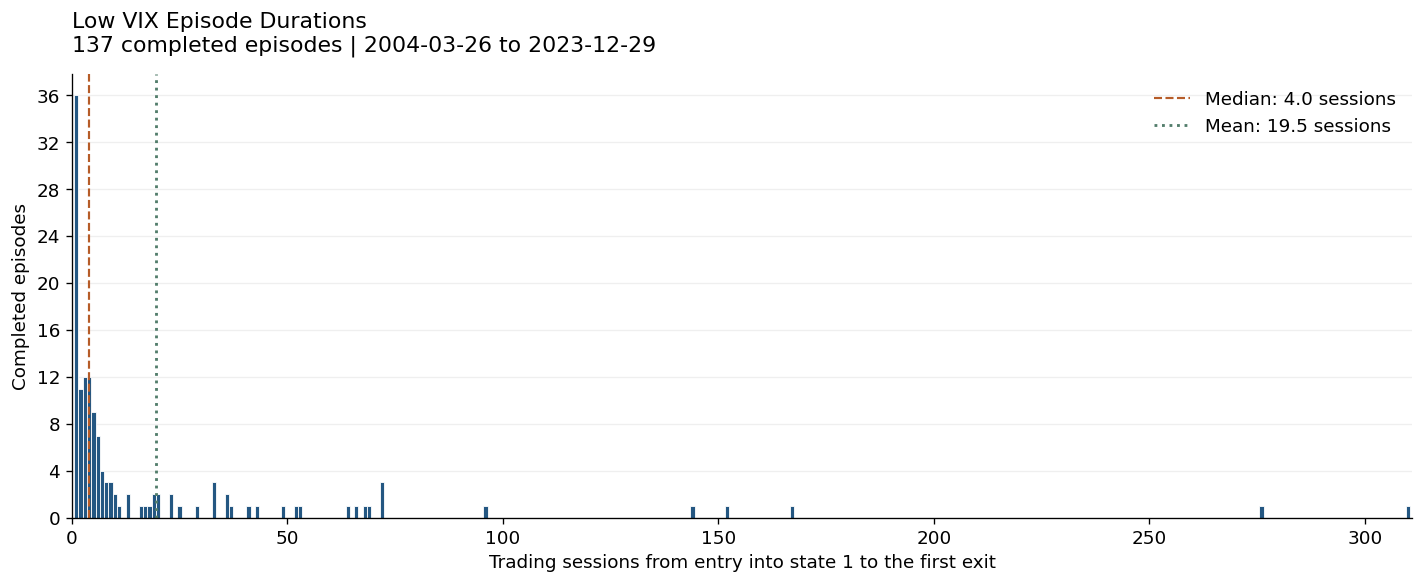

Horizon,Eligible episodes,Still continuously in state 1,Persistence probability
5 sessions,138,58,42.0%
15 sessions,138,36,26.1%


State,Observed days,Contango,Backwardation,Flat
1 · ≤P55,"2,738",97.4%,2.2%,0.5%


In [12]:
from matplotlib.ticker import MaxNLocator

# Include every observed entry into state 1, including a multiple-state drop.
low_episodes = entry_events.loc[entry_events["Entry state"] == 1].copy()
completed_low_episodes = low_episodes.loc[low_episodes["First exit"] != "Open"].copy()
open_low_episodes = low_episodes.loc[low_episodes["First exit"] == "Open"].copy()
low_durations = completed_low_episodes["Exit sessions"]
low_summary = pd.DataFrame([{
    "Sample": "Observed Low VIX entries", "Completed": len(completed_low_episodes),
    "Open at cutoff": len(open_low_episodes), "Minimum sessions": low_durations.min(),
    "Mean sessions": low_durations.mean(), "Median sessions": low_durations.median(),
    "Maximum sessions": low_durations.max(),
}]).set_index("Sample")
show_study_table(low_summary, "Low VIX Episodes — Duration until the First Exit above P55")

low_fig, low_ax = plt.subplots(figsize=(12, 5))
if not low_durations.empty:
    last_duration = int(low_durations.max())
    low_ax.hist(low_durations.to_numpy(dtype=int), bins=np.arange(0.5, last_duration + 1.5, 1),
                color="#245782", edgecolor="white", linewidth=0.5)
    low_ax.axvline(low_durations.median(), color="#b65c28", linestyle="--", linewidth=1.3,
                   label=f"Median: {low_durations.median():.1f} sessions")
    low_ax.axvline(low_durations.mean(), color="#527d6b", linestyle=":", linewidth=1.7,
                   label=f"Mean: {low_durations.mean():.1f} sessions")
    low_ax.set_xlim(0, last_duration + 1)
    low_ax.legend(frameon=False)
else:
    low_ax.text(0.5, 0.5, "No completed episodes", transform=low_ax.transAxes, ha="center")
low_ax.set_title(f"Low VIX Episode Durations\n{len(low_durations)} completed episodes | {period_label}",
                 loc="left", pad=14)
low_ax.set_xlabel("Trading sessions from entry into state 1 to the first exit")
low_ax.set_ylabel("Completed episodes")
low_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
low_ax.grid(axis="y", alpha=0.2)
low_ax.set_axisbelow(True)
low_fig.tight_layout()
plt.show()

low_persistence_rows = []
for horizon in HORIZONS:
    eligible_low = low_episodes.loc[low_episodes["Observed age"] >= horizon]
    # An exit exactly at h is not continuous survival through h.
    survivors = eligible_low["Exit sessions"].isna() | eligible_low["Exit sessions"].gt(horizon)
    low_persistence_rows.append({
        "Horizon": f"{horizon} sessions", "Eligible episodes": len(eligible_low),
        "Still continuously in state 1": int(survivors.sum()),
        "Persistence probability": survivors.mean() if len(eligible_low) else np.nan,
        "Incomplete follow-up": int((low_episodes["Observed age"] < horizon).sum()),
    })
low_persistence = pd.DataFrame(low_persistence_rows).set_index("Horizon")
show_study_table(low_persistence.drop(columns=["Incomplete follow-up"]), "Low VIX Persistence — No Exit and Reentry Allowed",
                 {"Persistence probability": "{:.1%}"})
# Section 6 verifies that F1 and F2 cover every date in the VIX study.
# This table therefore includes every observed Low VIX day.
low_curve_sample = curve_data.loc[(curve_data["State"] == 1) & curve_available].copy()
low_curve_summary = pd.DataFrame([{
    "State": STATE_NAMES[1], "Observed days": len(low_curve_sample),
    "Contango": low_curve_sample["Curve"].eq("Contango").mean() if len(low_curve_sample) else np.nan,
    "Backwardation": low_curve_sample["Curve"].eq("Backwardation").mean() if len(low_curve_sample) else np.nan,
    "Flat": low_curve_sample["Curve"].eq("Flat").mean() if len(low_curve_sample) else np.nan,
}]).set_index("State")
show_study_table(
    low_curve_summary, "Futures Curve during Low VIX — Full Study Period",
    {column: "{:.1%}" for column in ["Contango", "Backwardation", "Flat"]},
)
low_curve_coverage = curve_data.index[curve_available]
display(HTML(
    '<p style="font-size:13px;color:#536574;margin:0 0 18px;">'
    f'Futures data period: {low_curve_coverage.min():%Y-%m-%d} to {low_curve_coverage.max():%Y-%m-%d}. '
    f'All {len(low_curve_sample):,} Low VIX days have both F1 and F2.'
    '</p>'
))


<a id="section-8"></a>

## 8. VIX Behavior After Upward Entries

We study adjacent upward entries **1 → 2, 2 → 3, 3 → 4, and 4 → 5**.
The question is whether an increase tends to remain contained and relax soon,
or whether the VIX continues into a higher state.

For each horizon, the path table reports:

- **Lower exit first:** a lower state is the first state visited outside the
  entry range, and this exit occurs by the horizon.
- **Higher exit first:** a higher state is the first state visited outside the
  entry range, and this exit occurs by the horizon.
- **No exit yet:** the VIX stays continuously in the entry state through the
  horizon. These first three probabilities sum to 100% in each eligible row.
- **Reached state 1:** state 1 is visited at least once by the horizon,
  irrespective of earlier increases. This is an additional outcome, not a
  fourth mutually exclusive category.

The heatmap and transition diagram then show **where the VIX ends**. Rows and
arrow origins refer to the state entered at session 0; columns and destinations
refer to the state exactly 5 or 15 sessions later. Self-loops allow intermediate
exits and returns. Dashed arrows connect nonadjacent endpoint states; they do
not necessarily describe a single-day jump. All positive transitions are shown.

State 5 has no higher defined state. A zero higher-exit probability there is
structural, not evidence that further increases are harmless. We measure those
increases separately in subsection 8.3.


<a id="section-8-1"></a>

### 8.1. Five trading sessions


State,Eligible entries,Lower exit first,Higher exit first,No exit yet,Reached state 1
2 · P55–P76,133,72.2%,10.5%,17.3%,72.9%
3 · P76–P90,97,71.1%,11.3%,17.5%,5.2%
4 · P90–P96,51,66.7%,7.8%,25.5%,0.0%
5 · >P96,17,82.4%,0.0%,17.6%,0.0%


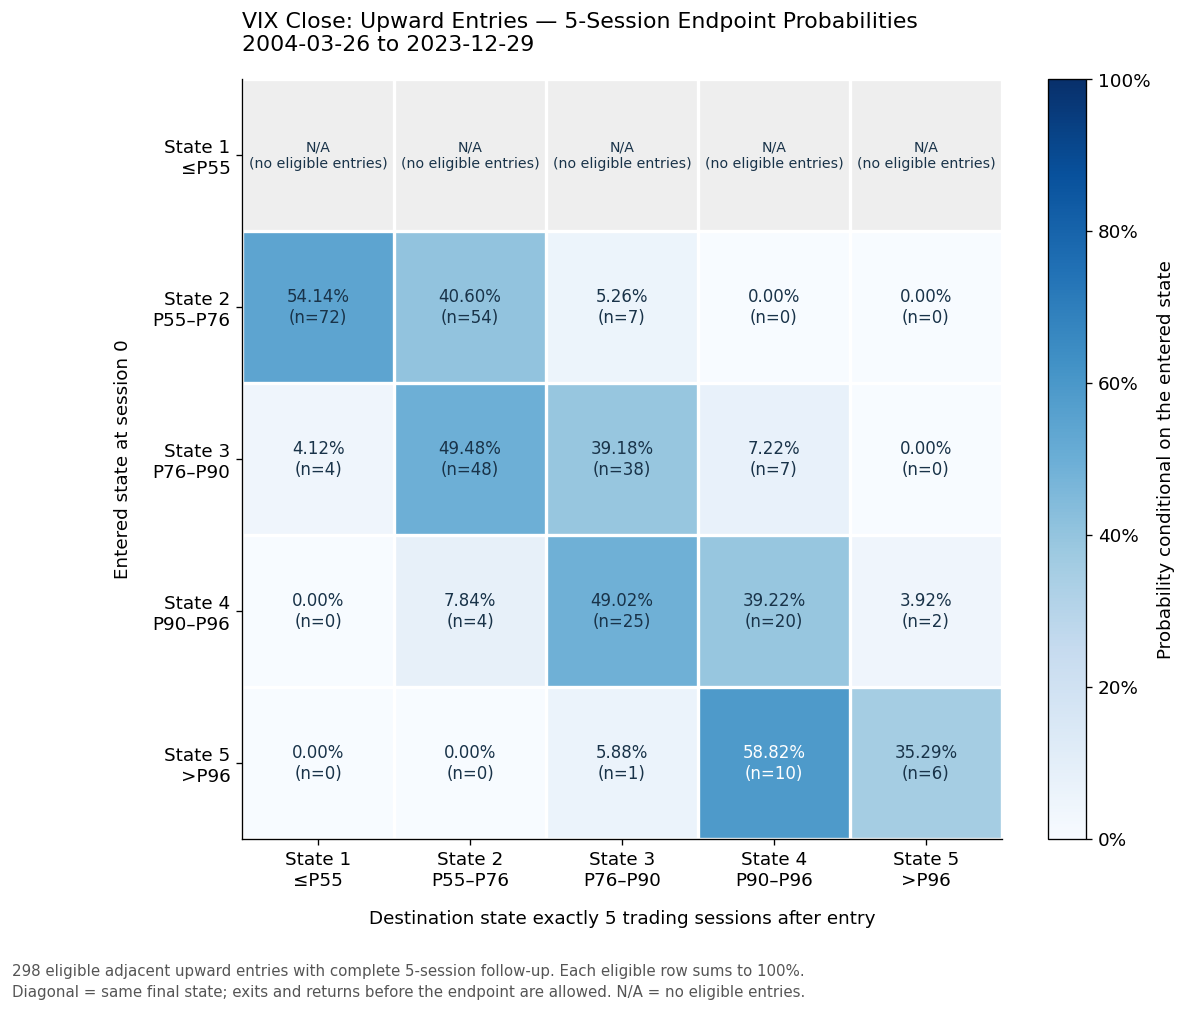

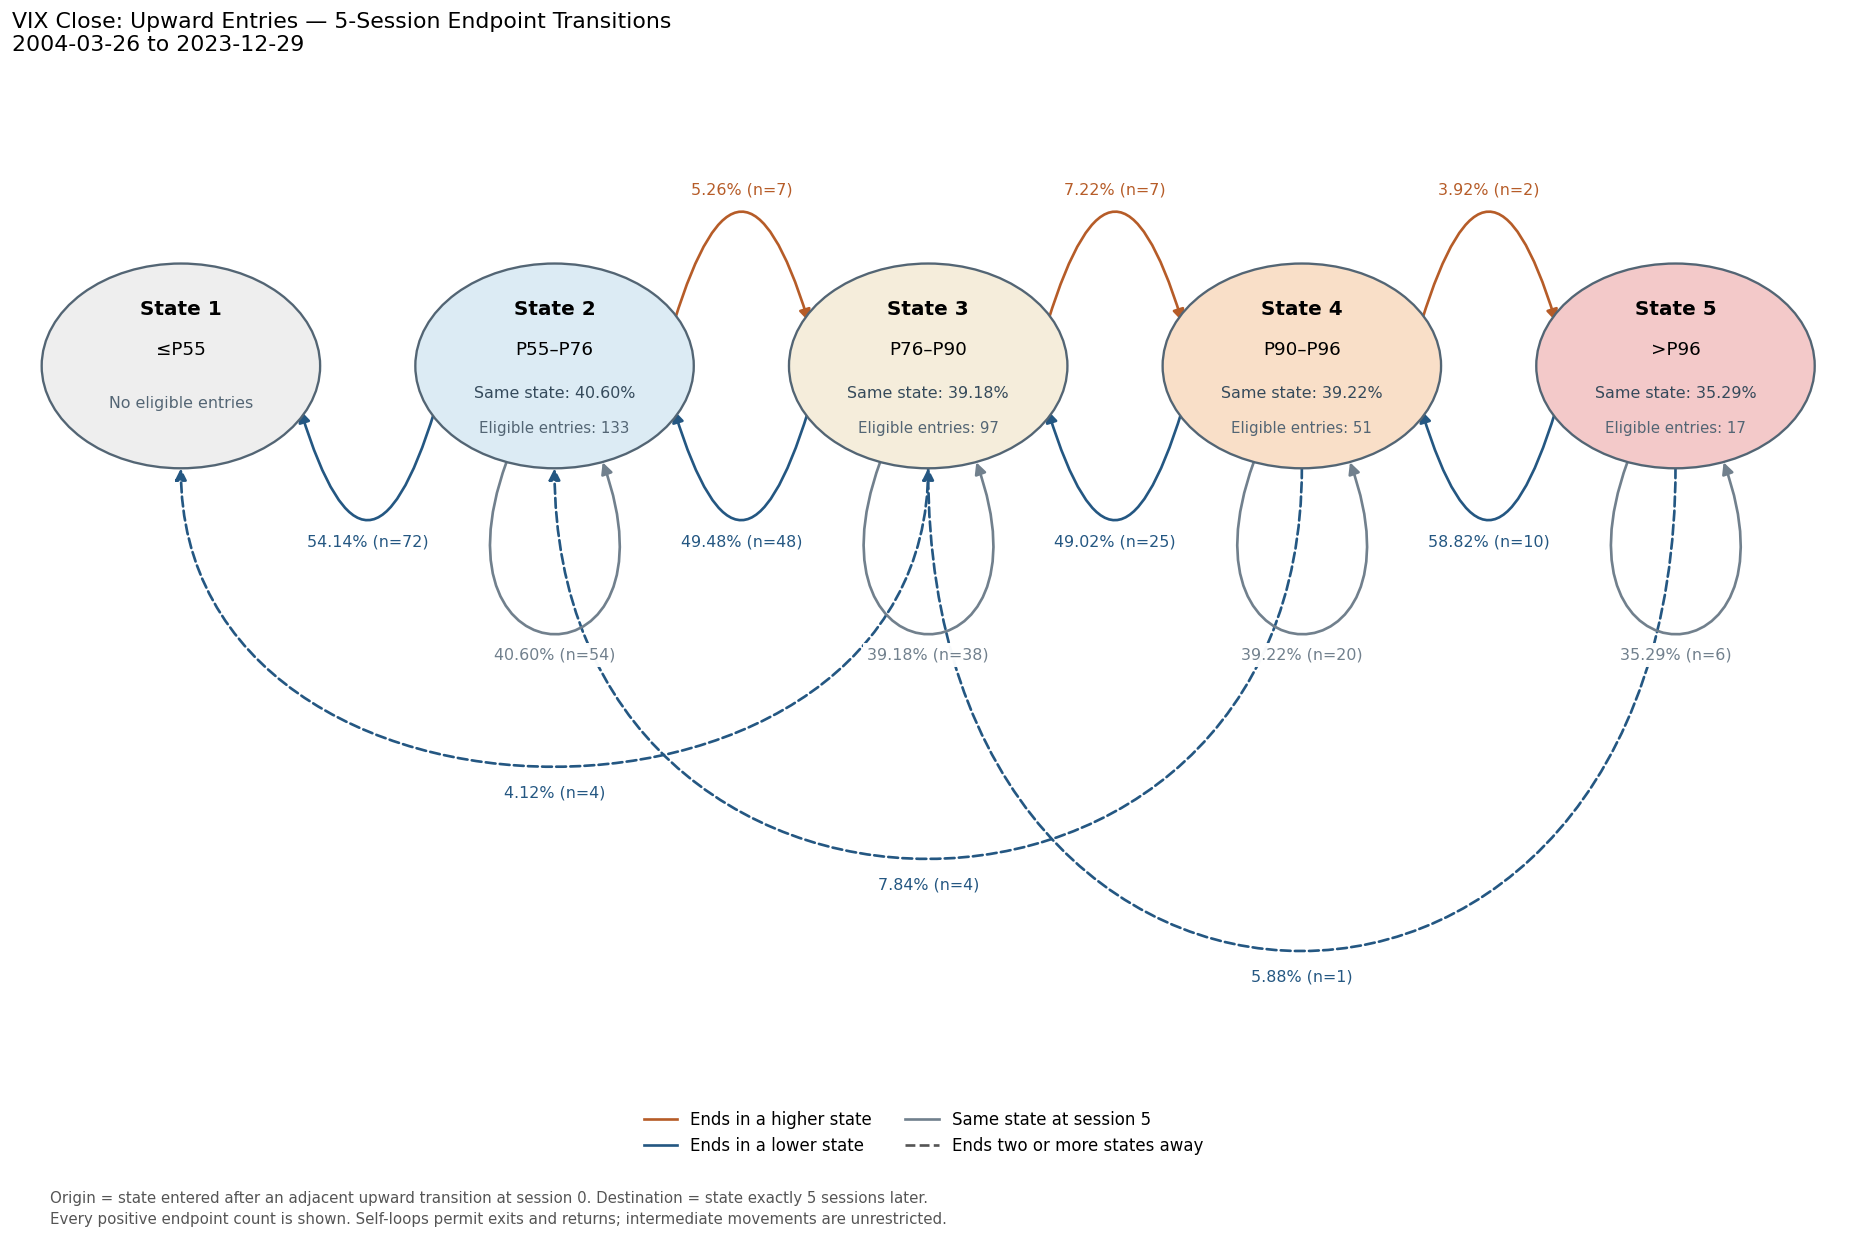

In [13]:
show_entry_horizon("Upward", 5, show_incomplete_follow_up=False)


<a id="section-8-2"></a>

### 8.2. Fifteen trading sessions


State,Eligible entries,Lower exit first,Higher exit first,No exit yet,Reached state 1
2 · P55–P76,133,83.5%,16.5%,0.0%,89.5%
3 · P76–P90,97,79.4%,17.5%,3.1%,22.7%
4 · P90–P96,51,90.2%,9.8%,0.0%,3.9%
5 · >P96,17,88.2%,0.0%,11.8%,0.0%


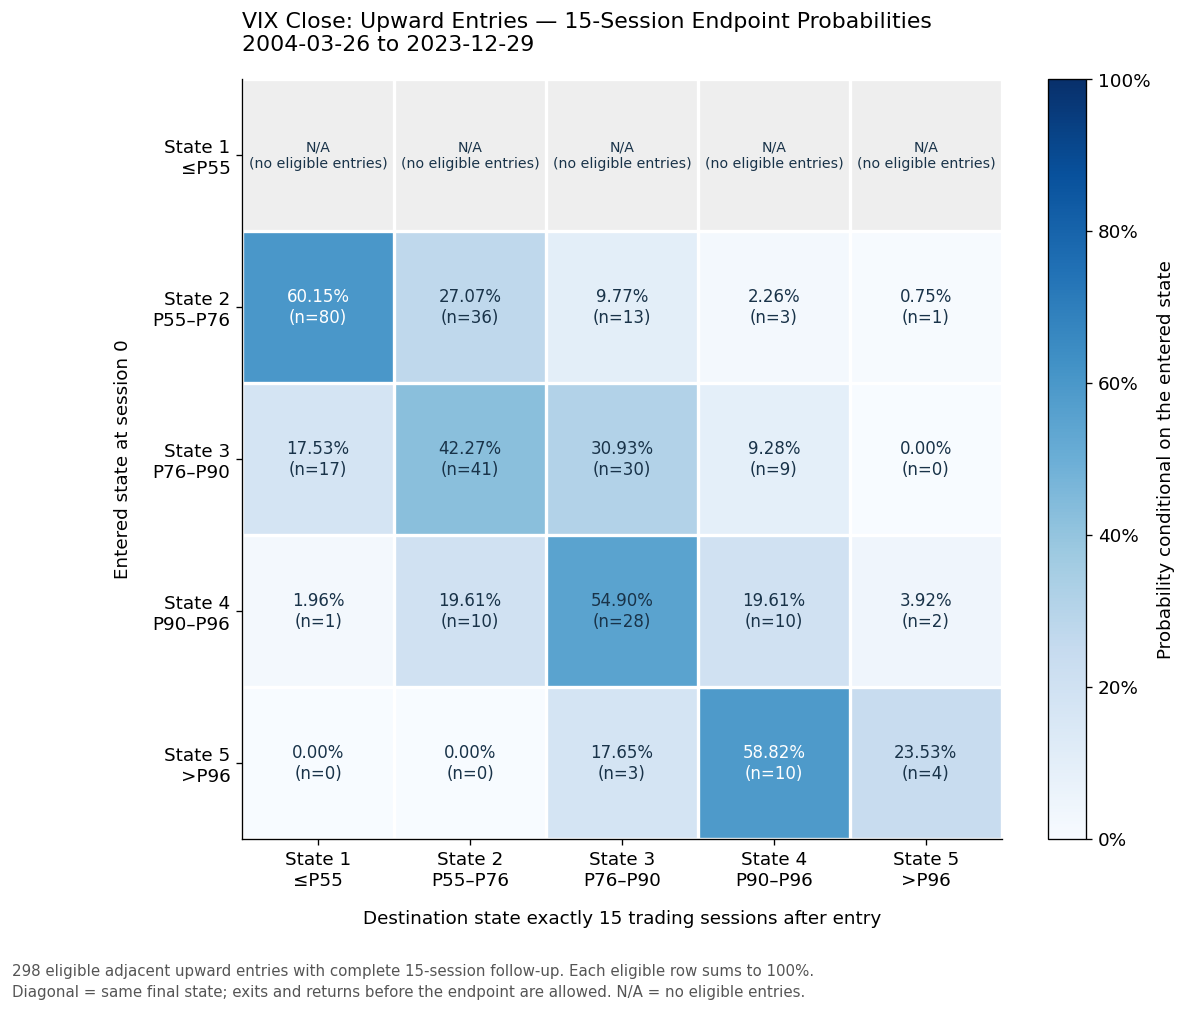

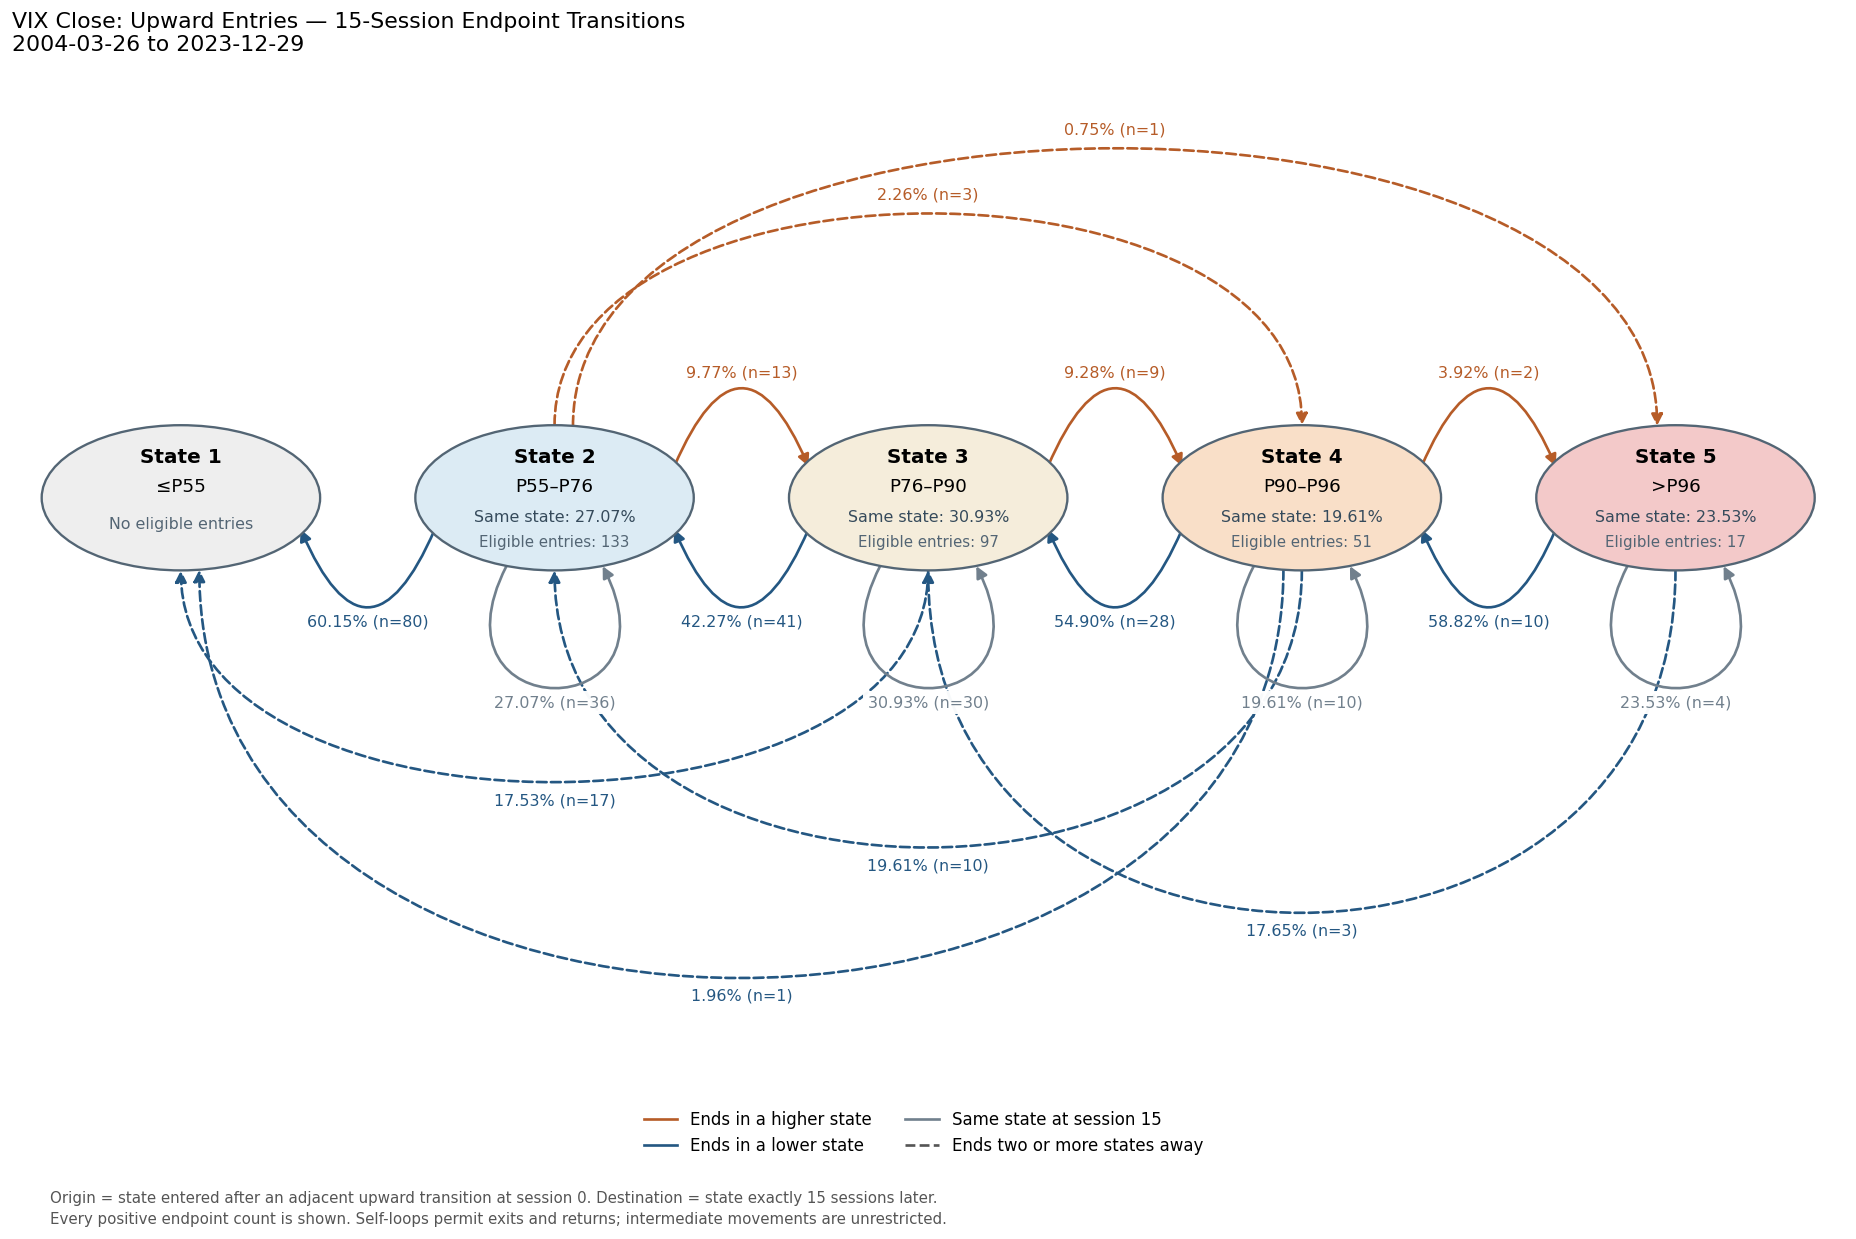

In [14]:
show_entry_horizon("Upward", 15, show_incomplete_follow_up=False)


<a id="section-8-3"></a>

### 8.3. Time to a lower first exit

The mean, median, and histograms describe entries whose **first exit is lower**:
the VIX stays in its entry range until that exit. Their full observed durations
are not capped at 15 sessions. Higher-first exits and open events are counted
alongside them, but excluded from these conditional duration statistics.
We cannot know at entry which group an event will eventually belong to.

For state 5, the range has no upper limit. The additional table measures the
maximum increase in daily Close from the entry Close during the next 15
sessions, including session 0. It is zero if no later Close exceeds entry.
Values are **VIX index points**, not investment drawdowns. The P90 value is
the 90th percentile across these event-level maximum increases.


State,Entries,Higher first,Lower first,Mean sessions,Median sessions
2 · P55–P76,133,22,111,3.06,2.00
3 · P76–P90,97,18,79,3.01,2.00
4 · P90–P96,51,5,46,3.87,2.50
5 · >P96,17,0,17,11.41,2.00


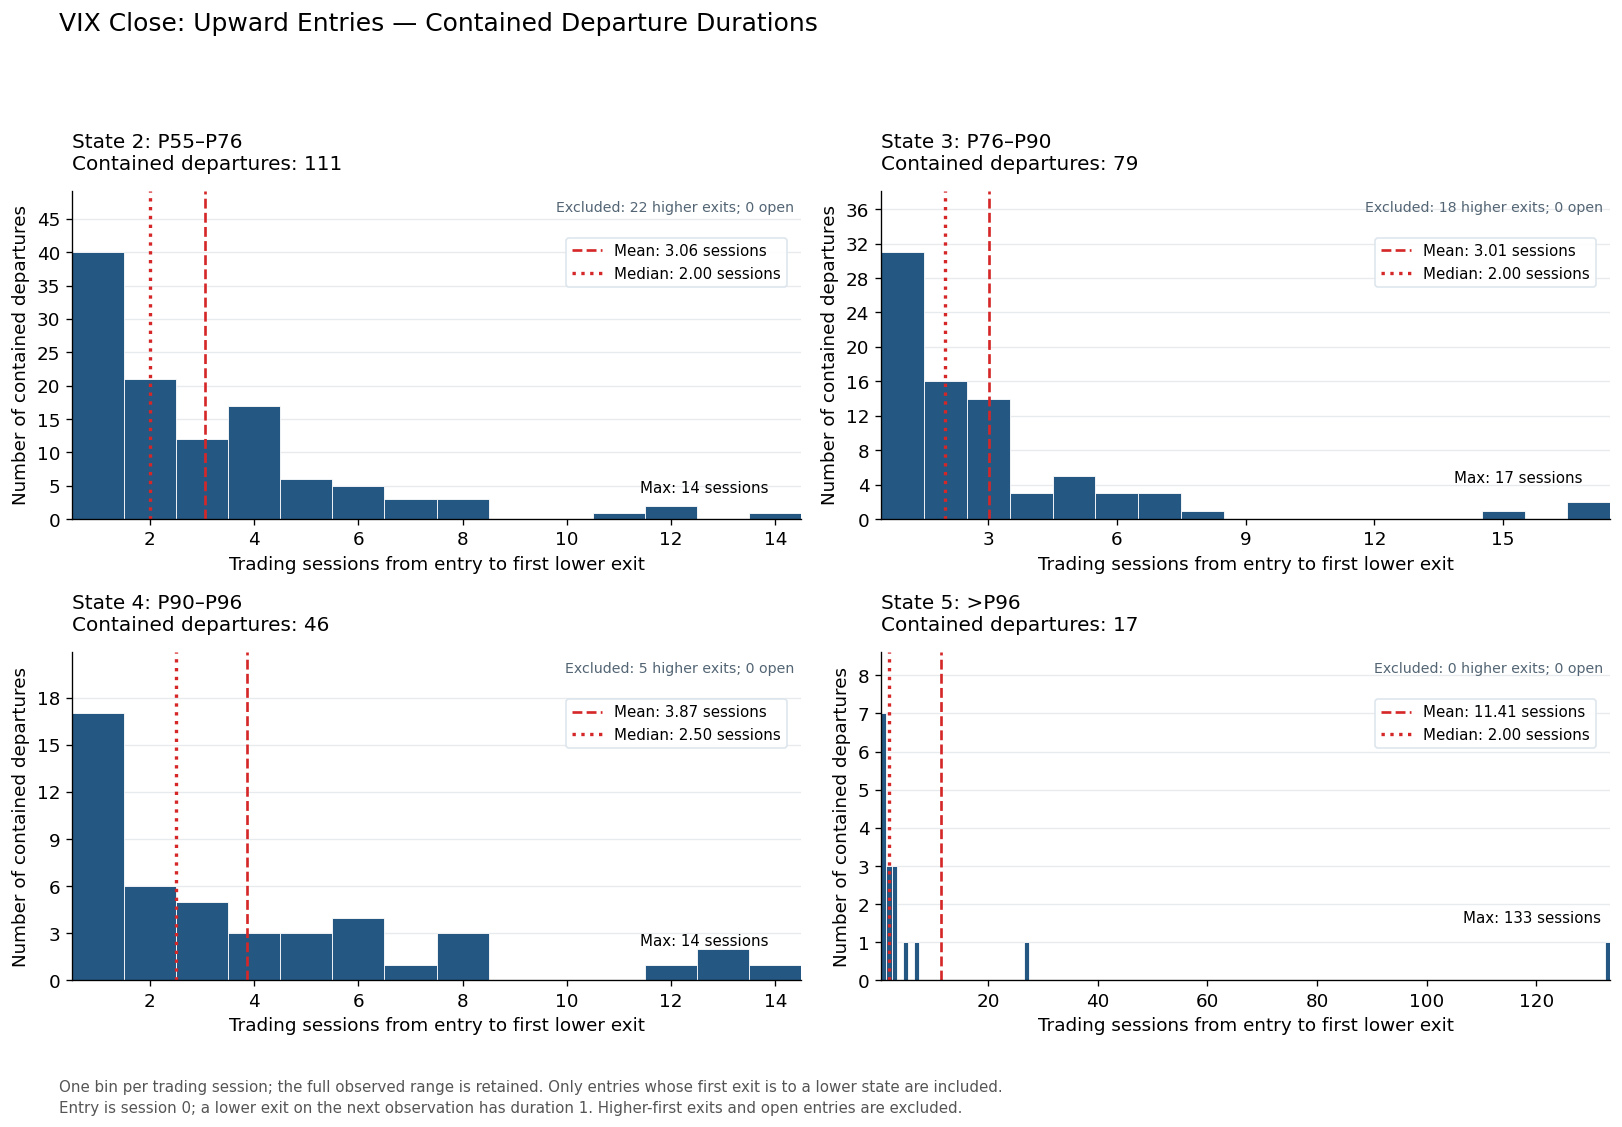

State,Eligible entries,Median maximum increase,P90 maximum increase,Largest observed increase
5 · >P96,17,0.22,12.35,43.07


In [15]:
show_contained_report(
    "Upward", show_open_at_cutoff=False,
    column_order=["Entries", "Higher first", "Lower first", "Mean sessions", "Median sessions"],
)
top_state_exposure = show_top_state_exposure()


<a id="section-9"></a>

## 9. VIX Behavior After Downward Entries

We study adjacent downward entries **3 → 2, 4 → 3, and 5 → 4**, using the
same path measures and endpoint matrices as section 8. Entries into state 1
are covered by section 7.

The question is whether the VIX continues relaxing after entering from above,
or reverses into a higher state. **Downward entry describes the starting
condition, not a restriction on the subsequent path.** Every eligible entry
is included, even if the VIX later rises. For example, a 5 → 4 entry that ends
in state 5 is counted as an upward outcome from entry state 4.

The three first-exit categories sum to 100%; reaching state 1 is a separate
path outcome. The heatmap and diagram retain all five possible destination
states, including upward reversals.


<a id="section-9-1"></a>

### 9.1. Five trading sessions


State,Eligible entries,Lower exit first,Higher exit first,No exit yet,Reached state 1
2 · P55–P76,103,11.7%,53.4%,35.0%,11.7%
3 · P76–P90,56,12.5%,44.6%,42.9%,0.0%
4 · P90–P96,20,15.0%,45.0%,40.0%,0.0%


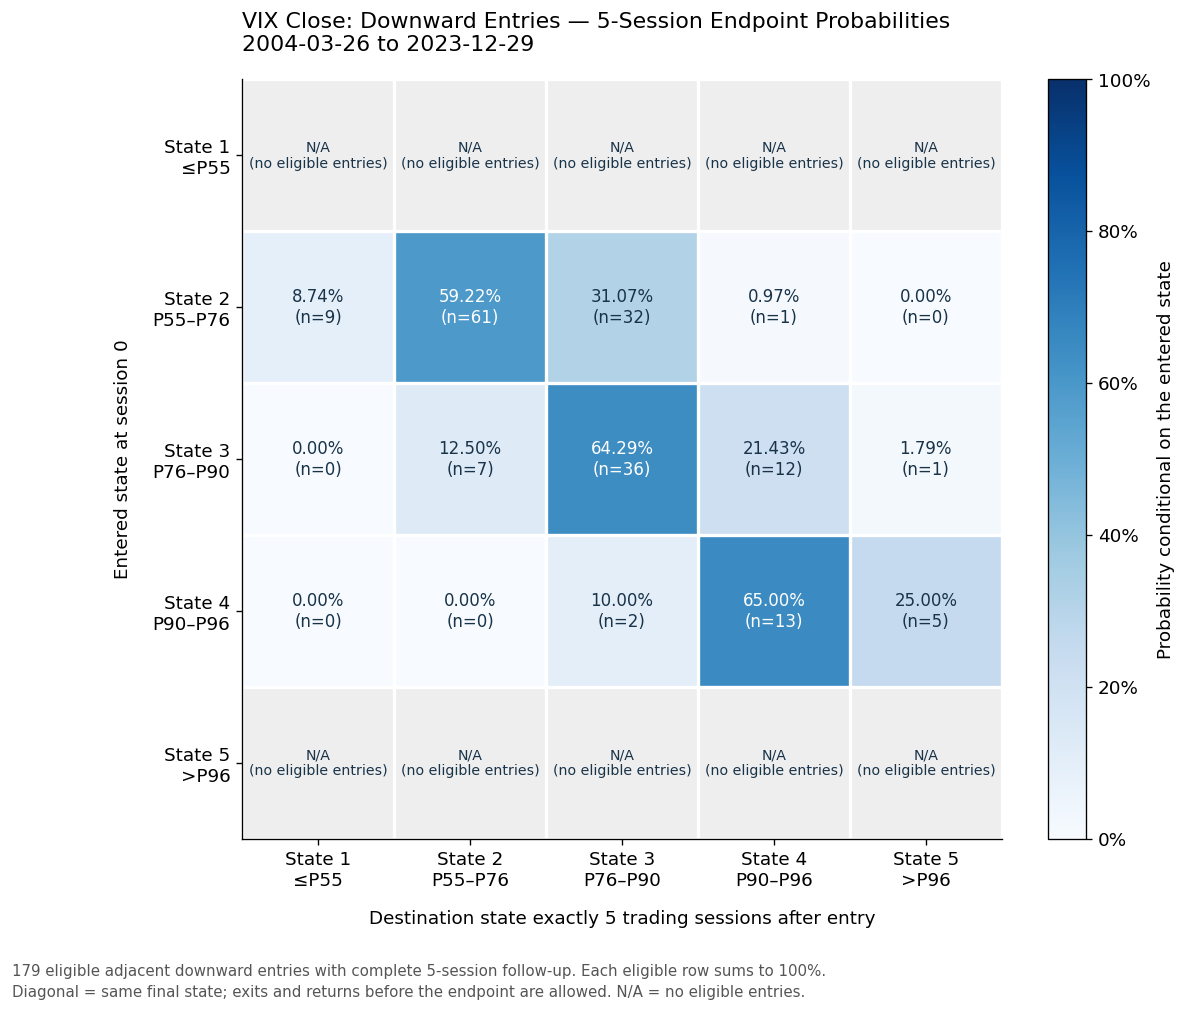

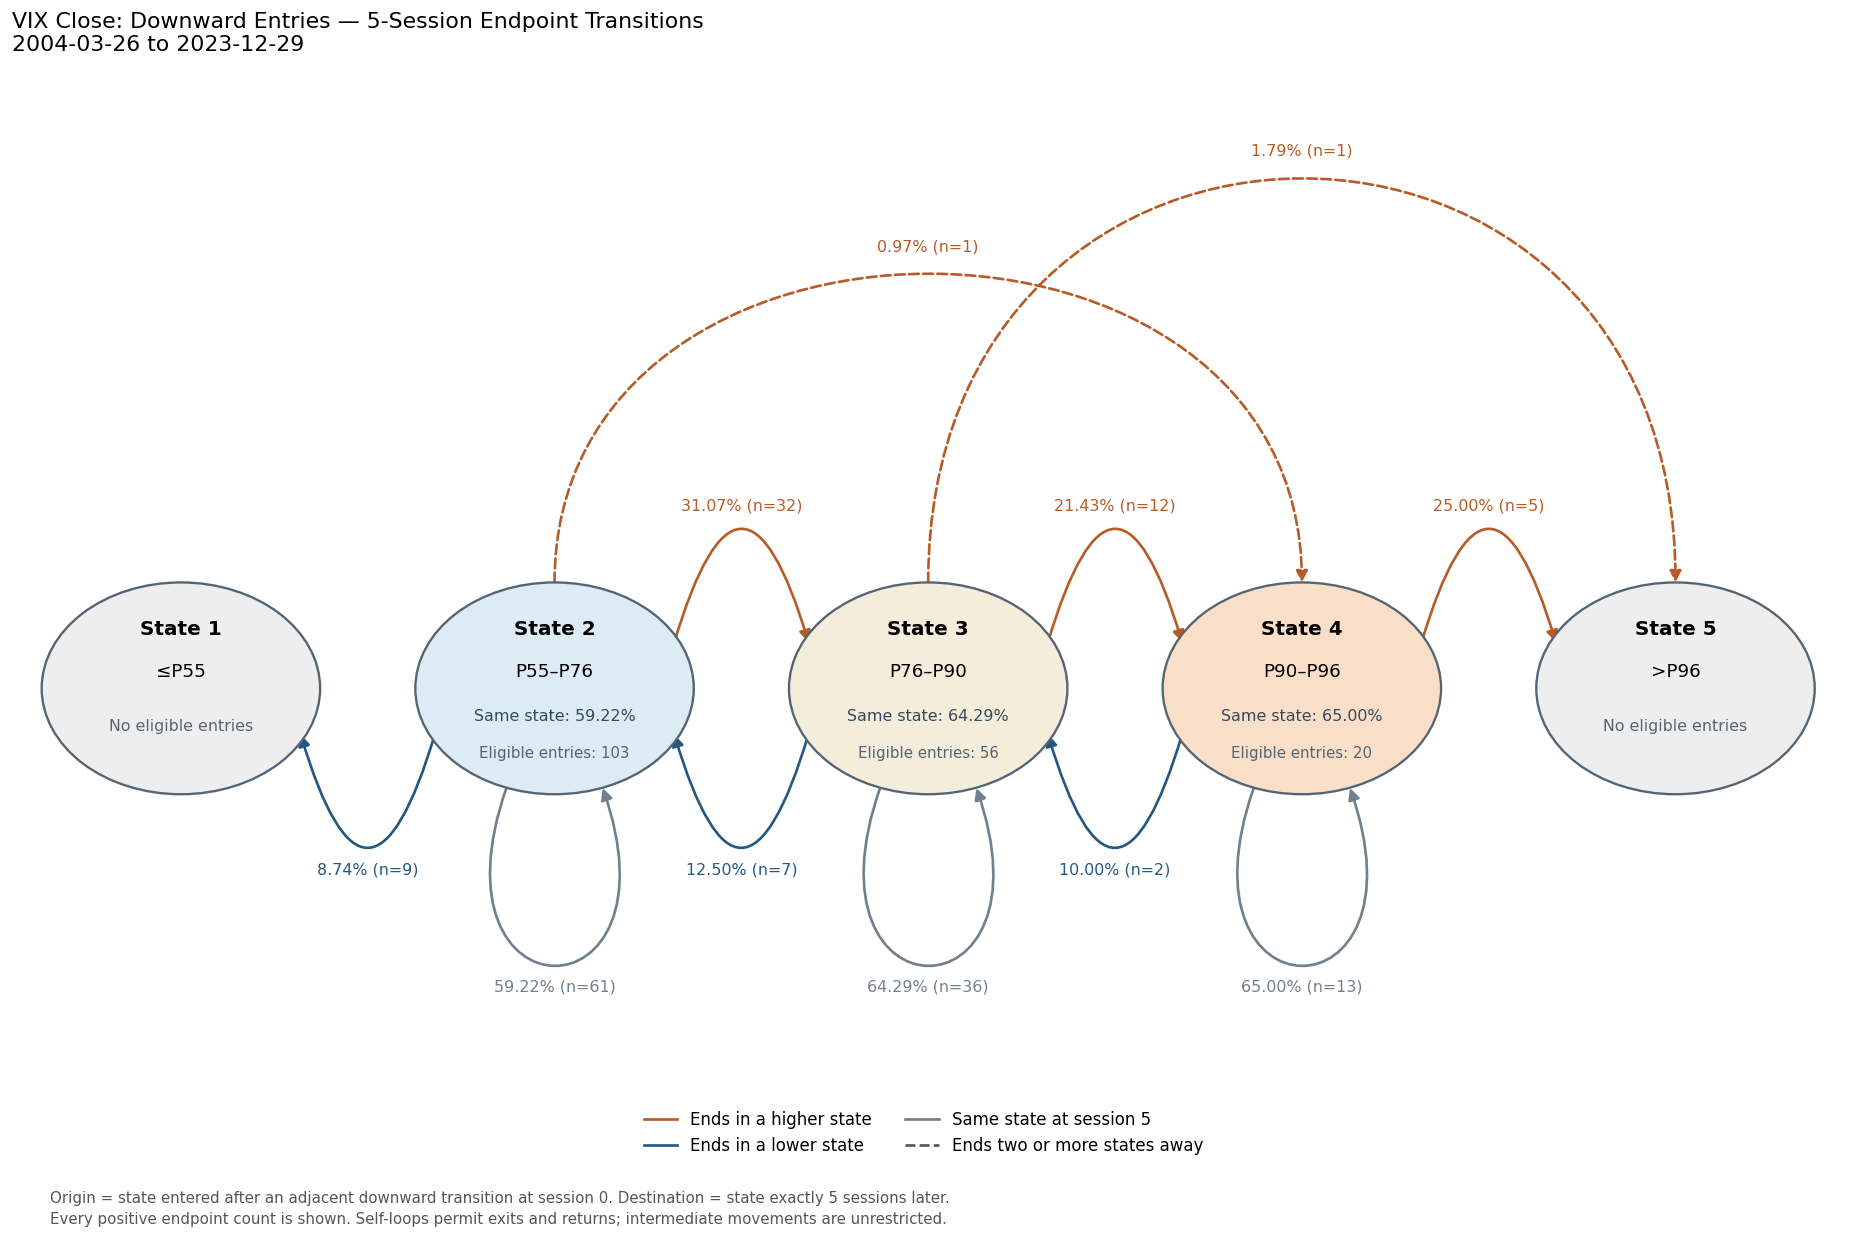

In [16]:
show_entry_horizon("Downward", 5)


<a id="section-9-2"></a>

### 9.2. Fifteen trading sessions


State,Eligible entries,Lower exit first,Higher exit first,No exit yet,Reached state 1
2 · P55–P76,103,24.3%,69.9%,5.8%,31.1%
3 · P76–P90,56,30.4%,58.9%,10.7%,5.4%
4 · P90–P96,20,40.0%,60.0%,0.0%,0.0%


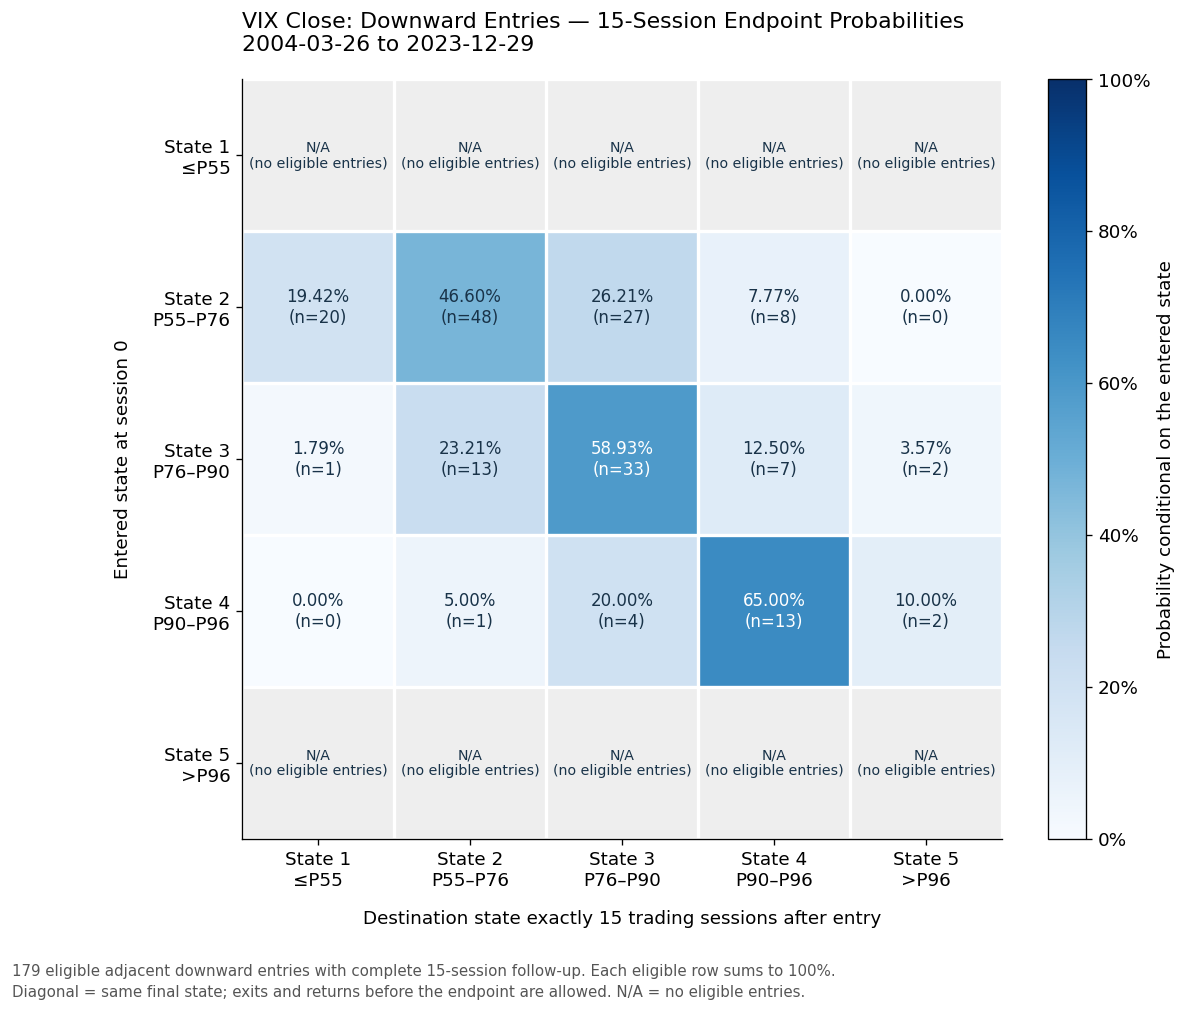

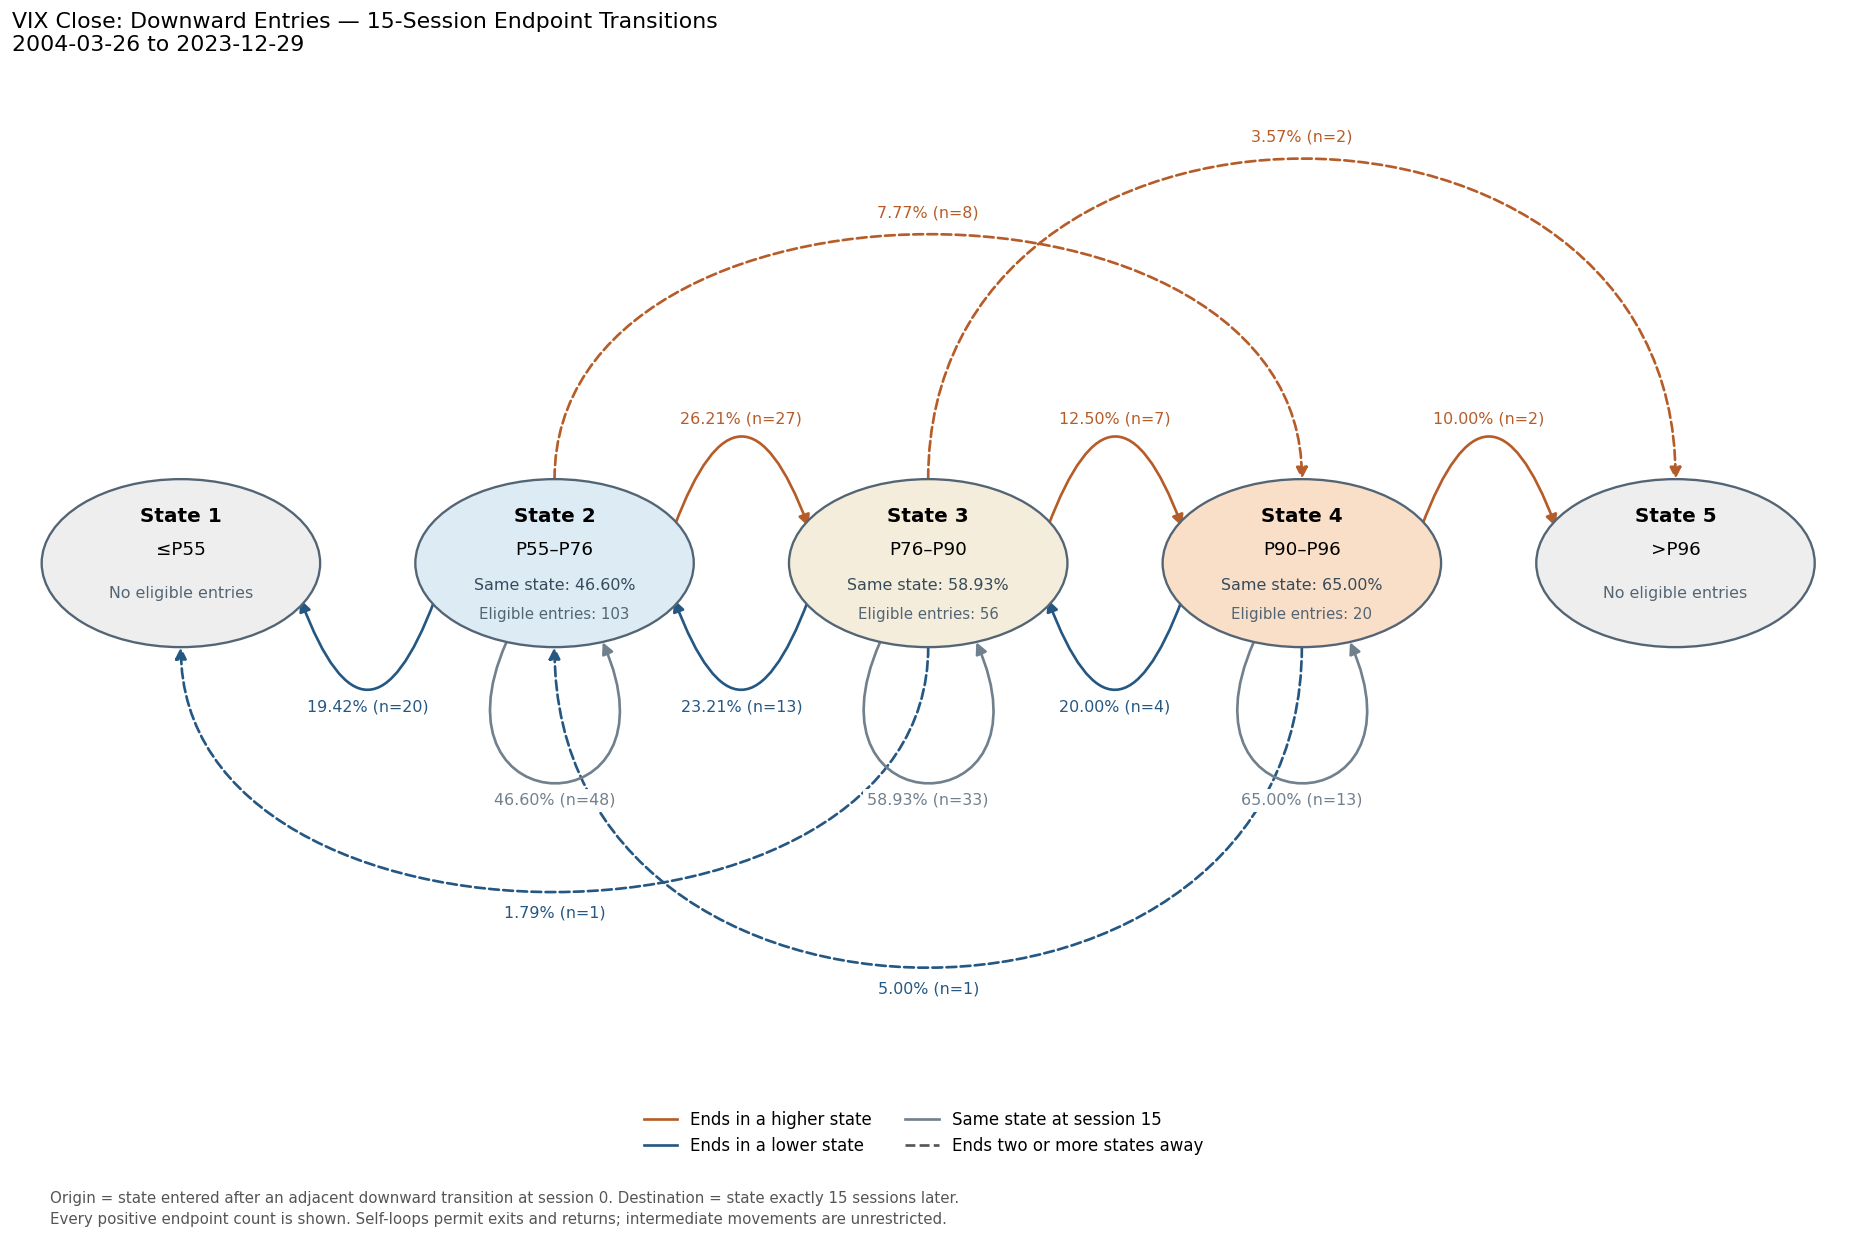

In [17]:
show_entry_horizon("Downward", 15)


<a id="section-9-3"></a>

### 9.3. Time to a lower state with a rebound allowance

After a downward entry into state 2, 3, or 4, follow daily Close until one of
these conditions occurs first:

- **Lower state reached:** Close is at or below the entry state's lower boundary.
- **Rebound limit exceeded:** Close is strictly above the entry state's upper
  boundary multiplied by **1.12**, allowing a **12% rebound above that boundary**.
  A Close exactly at this limit is allowed.

Rebounds within this allowance do not end the event or restart the clock.
The 12% allowance is measured from the **upper boundary**, not from the entry Close.
There is no fixed time horizon: use the full observed period through the study cutoff.
Once either condition occurs, the outcome is final, regardless of later movements.

The mean, median, and histograms include only entries that reach a lower state
before exceeding the rebound limit. They include both direct declines and declines
after allowed rebounds, counting sessions from the original entry (session 0).
Unresolved events are counted separately if any remain at the cutoff and are
excluded from these duration statistics. Each observed entry remains a separate
event, so observation windows may overlap.


State,Entries,Rebound limit exceeded first,Lower state reached first,Mean sessions,Median sessions
2 · P55–P76,103,59,44,15.27,9.50
3 · P76–P90,56,21,35,17.23,12.00
4 · P90–P96,20,8,12,11.00,11.00


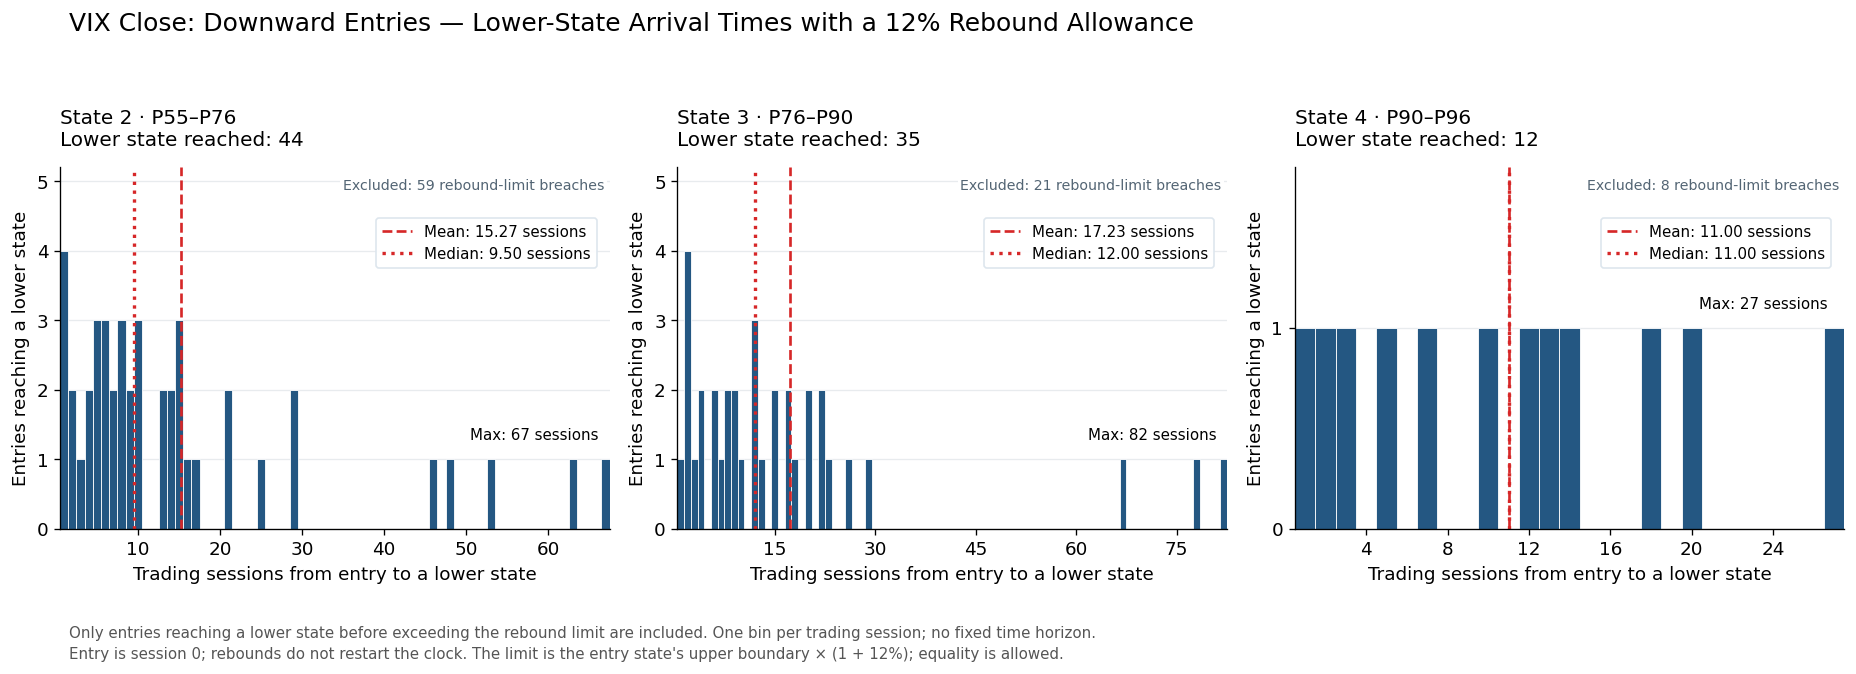

In [18]:
from matplotlib.ticker import MaxNLocator

DOWNWARD_REBOUND_TOLERANCE_PCT = 0.12  # Fraction of the entry state's upper boundary.
if DOWNWARD_REBOUND_TOLERANCE_PCT < 0:
    raise ValueError("The rebound tolerance must be nonnegative.")

rebound_records = []
for _, entry in primary_entries["Downward"].iterrows():
    state = int(entry["Entry state"])
    position = int(entry["Start position"])
    lower_boundary = float(study_thresholds.iloc[state - 2])
    upper_boundary = float(study_thresholds.iloc[state - 1])
    rebound_limit = upper_boundary * (1 + DOWNWARD_REBOUND_TOLERANCE_PCT)
    future = vix["Close"].iloc[position + 1:].to_numpy(dtype=float)
    hits = np.flatnonzero((future <= lower_boundary) | (future > rebound_limit))
    elapsed = int(hits[0] + 1) if hits.size else np.nan
    outcome = "Unresolved"
    rebound_before_lower = False
    if hits.size:
        if future[hits[0]] <= lower_boundary:
            outcome = "Lower reached"
            rebound_before_lower = bool(np.any(future[:hits[0]] > upper_boundary))
        else:
            outcome = "Rebound limit exceeded"
    rebound_records.append({
        "Event": int(entry["Event"]), "Start": entry["Start"], "Entry state": state,
        "Lower boundary": lower_boundary, "Upper boundary": upper_boundary,
        "Rebound limit": rebound_limit, "Outcome": outcome, "Sessions": elapsed,
        "Rebound before lower": rebound_before_lower,
    })
downward_rebound_events = pd.DataFrame(rebound_records)

rebound_summary_rows = []
for state in [2, 3, 4]:
    entries = downward_rebound_events.loc[downward_rebound_events["Entry state"] == state]
    durations = entries.loc[entries["Outcome"] == "Lower reached", "Sessions"]
    rebound_summary_rows.append({
        "State": STATE_NAMES[state], "Entries": len(entries),
        "Rebound limit exceeded first": int(entries["Outcome"].eq("Rebound limit exceeded").sum()),
        "Unresolved": int(entries["Outcome"].eq("Unresolved").sum()),
        "Lower state reached first": len(durations),
        "Mean sessions": durations.mean(), "Median sessions": durations.median(),
    })
downward_rebound_summary = pd.DataFrame(rebound_summary_rows).set_index("State")
rebound_table = downward_rebound_summary
if rebound_table["Unresolved"].eq(0).all():
    rebound_table = rebound_table.drop(columns="Unresolved")
show_study_table(
    rebound_table,
    f"Downward Entries — Time to a Lower State with a {DOWNWARD_REBOUND_TOLERANCE_PCT:.0%} Rebound Allowance",
)

rebound_fig, rebound_axes = plt.subplots(1, 3, figsize=(16, 5.6))
for state, ax in zip([2, 3, 4], rebound_axes):
    entries = downward_rebound_events.loc[downward_rebound_events["Entry state"] == state]
    durations = entries.loc[entries["Outcome"] == "Lower reached", "Sessions"].to_numpy(dtype=int)
    adverse_count = int(entries["Outcome"].eq("Rebound limit exceeded").sum())
    unresolved_count = int(entries["Outcome"].eq("Unresolved").sum())
    if len(durations):
        maximum = int(durations.max())
        heights, _, _ = ax.hist(durations, bins=np.arange(0.5, maximum + 1.5, 1),
                                color="#245782", edgecolor="white", linewidth=0.5)
        ax.set_xlim(0.5, maximum + 0.5)
        ax.set_ylim(0, max(heights) * (1.8 if max(heights) == 1 else 1.3))
        ax.axvline(durations.mean(), color="#d62728", linestyle="--", linewidth=1.6,
                   label=f"Mean: {durations.mean():.2f} sessions")
        ax.axvline(np.median(durations), color="#d62728", linestyle=":", linewidth=2.0,
                   label=f"Median: {np.median(durations):.2f} sessions")
        ax.legend(loc="upper right", bbox_to_anchor=(0.99, 0.88), fontsize=9,
                  frameon=True, facecolor="white", edgecolor="#dce5ed", framealpha=0.95)
        ax.annotate(f"Max: {maximum} sessions", xy=(maximum, heights[-1]),
                    xytext=(-4, 10), textcoords="offset points", ha="right", va="bottom", fontsize=9)
    else:
        ax.text(0.5, 0.5, "No lower-state arrivals", transform=ax.transAxes, ha="center")
    ax.set_title(f"State {STATE_NAMES[state]}\nLower state reached: {len(durations):,}",
                 loc="left", fontsize=12, pad=13)
    exclusion = f"Excluded: {adverse_count:,} rebound-limit breaches"
    if unresolved_count:
        exclusion += f"; {unresolved_count:,} unresolved"
    ax.text(0.99, 0.97, exclusion, transform=ax.transAxes, ha="right", va="top",
             fontsize=8.5, color="#536574", bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
    ax.set_xlabel("Trading sessions from entry to a lower state")
    ax.set_ylabel("Entries reaching a lower state")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8, min_n_ticks=1))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", color="#d9dee4", alpha=0.6)
    ax.set_axisbelow(True)
rebound_fig.suptitle(
    f"VIX Close: Downward Entries — Lower-State Arrival Times with a {DOWNWARD_REBOUND_TOLERANCE_PCT:.0%} Rebound Allowance",
    x=0.055, y=0.99, ha="left", fontsize=15,
)
rebound_fig.text(
    0.055, 0.022,
    "Only entries reaching a lower state before exceeding the rebound limit are included. "
    "One bin per trading session; no fixed time horizon.\n"
    "Entry is session 0; rebounds do not restart the clock. "
    f"The limit is the entry state's upper boundary × (1 + {DOWNWARD_REBOUND_TOLERANCE_PCT:.0%}); equality is allowed.",
    ha="left", va="bottom", fontsize=9, color="#555555", linespacing=1.5,
)
rebound_fig.tight_layout(rect=(0.015, 0.11, 0.99, 0.94))
plt.show()


<a id="section-10"></a>

## 10. Comparison of Entry Conditions

We compare upward and downward entries into the same state over **15 trading
sessions**. The five-session results remain available in sections 8 and 9.
Each row uses all eligible entries with full follow-up, including unsuccessful
outcomes. The table brings together the probability of a lower first exit,
the probability of a higher first exit, and the probability of reaching state 1.

The median time to a lower exit is conditional on that lower first exit
occurring **within 15 sessions**. Section 8.3 uses unrestricted lower-first
durations; section 9.3 separately allows a rebound above the upper state boundary.
The rebound allowance does not change this comparison. The P90 maximum VIX increase uses **every
eligible entry**, including those that later relax, and is measured in index
points. It describes changes in Close, not intraday extremes or investment loss.

Upward entries often begin near the lower boundary, while downward entries
often begin near the upper boundary. Mean entry Close is included so that
differences are not attributed to direction alone. Event counts also matter:
small groups and overlapping observations limit how confidently we can
generalize these descriptive frequencies.

The second table checks how often each state coincides with contango,
backwardation, or a flat curve. These are daily frequencies using F1/F2
observations matched to every VIX date in the full study period, from
**March 26, 2004 through December 29, 2023**. Futures observations after the
study cutoff are excluded.


In [19]:
comparison_rows = []
for state in [2, 3, 4]:
    for direction in ["Upward", "Downward"]:
        result = directional_results[direction][15]
        sample = result["eligible"].loc[result["eligible"]["Entry state"] == state]
        n = len(sample)
        lower_times = sample.loc[sample["First exit by horizon"] == "Lower", "Exit sessions"]
        comparison_rows.append({
            "Entry condition": f"State {state} · {direction}", "Eligible entries": n,
            "Mean entry Close": sample["Entry Close"].mean(),
            "Lower exit first": (sample["First exit by horizon"] == "Lower").mean() if n else np.nan,
            "Higher exit first": (sample["First exit by horizon"] == "Higher").mean() if n else np.nan,
            "Reached state 1": sample["Reached Low VIX"].mean() if n else np.nan,
            "Median sessions to lower exit": lower_times.median(),
            "P90 maximum VIX increase": sample["Maximum VIX increase"].quantile(0.90),
        })
entry_comparison_15 = pd.DataFrame(comparison_rows).set_index("Entry condition")
show_study_table(
    entry_comparison_15, "Upward versus Downward Entries — 15-Session Comparison",
    {column: "{:.1%}" for column in ["Lower exit first", "Higher exit first", "Reached state 1"]},
)
show_study_table(curve_by_state, "Futures-Curve Conditions by VIX State — Full Study Period",
                 {column: "{:.1%}" for column in ["Contango", "Backwardation", "Flat"]})
curve_dates = curve_data.index[curve_available]
print(f"Matched futures period: {curve_dates.min():%Y-%m-%d} to {curve_dates.max():%Y-%m-%d}; "
      f"all {len(curve_data):,} VIX study days have both F1 and F2.")


Matched futures period: 2004-03-26 to 2023-12-29; all 4,975 VIX study days have both F1 and F2.


Entry condition,Eligible entries,Mean entry Close,Lower exit first,Higher exit first,Reached state 1,Median sessions to lower exit,P90 maximum VIX increase
State 2 · Upward,133,18.41,83.5%,16.5%,89.5%,2.00,7.40
State 2 · Downward,103,21.61,24.3%,69.9%,31.1%,6.00,9.91
State 3 · Upward,97,23.84,79.4%,17.5%,22.7%,2.00,11.15
State 3 · Downward,56,27.34,30.4%,58.9%,5.4%,6.00,10.02
State 4 · Upward,51,30.89,90.2%,9.8%,3.9%,2.50,11.10
State 4 · Downward,20,36.00,40.0%,60.0%,0.0%,8.50,9.38


State,Matched days,Contango,Backwardation,Flat
1 · ≤P55,"2,738",97.4%,2.2%,0.5%
2 · P55–P76,"1,044",82.7%,16.5%,0.9%
3 · P76–P90,695,74.0%,25.9%,0.1%
4 · P90–P96,300,37.3%,62.0%,0.7%
5 · >P96,198,9.1%,89.9%,1.0%
